## Imports and configuration

In [1]:
# IMPORTS AND GLOBAL SETUP
# This cell loads the Python libraries used throughout the project.
# In simple terms: it prepares tools for file handling, data tables, numerical calculations, progress bars, plotting, and data validation.

import os
import re
import gc
import warnings
from pathlib import Path
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("Environment ready.")

Environment ready.


In [2]:
# INPUT AND OUTPUT LOCATIONS
# This cell defines where the original EdNet data is read from and where processed results will be saved.
# It also limits the first execution to a manageable development subset instead of immediately processing the entire dataset.


INPUT_DIR = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/cse753_processed")

# During development, keep this at 100.
# Set to None to process every u*.csv file.
MAX_STUDENTS = 100

# Minimum number of RL transitions required for a student
# to be retained in the final RL dataset.
MIN_EPISODE_LENGTH = 5

RANDOM_STATE = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_DIR :", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("MAX_STUDENTS:", MAX_STUDENTS)

INPUT_DIR : /kaggle/input
OUTPUT_DIR: /kaggle/working/cse753_processed
MAX_STUDENTS: 100


In [3]:
# CHECK REQUIRED WORKING FOLDERS
# Before processing starts, this cell verifies that the Kaggle input directory exists.
# If the dataset is not available, the program stops early with a clear error instead of failing later.

if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Kaggle input directory not found: {INPUT_DIR}"
    )

all_csv_files = sorted(INPUT_DIR.rglob("*.csv"))

print("Total CSV files found:", len(all_csv_files))

for f in all_csv_files[:30]:
    print(" ", f)

Total CSV files found: 297919
  /kaggle/input/datasets/oishyislam/contents/coupons.csv
  /kaggle/input/datasets/oishyislam/contents/lectures.csv
  /kaggle/input/datasets/oishyislam/contents/payments.csv
  /kaggle/input/datasets/oishyislam/contents/questions.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u1.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u10.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u100.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u1000.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u10004.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u100043.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u10005.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u1001.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u10010.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u10011.csv
  /kaggle/input/datasets/oishyislam/ednet-dataset/KT3/u10013.csv
  /kaggle/input/datasets/oishyisl

In [4]:
# LOCATE CORE DATASET FILES
# This cell searches the input folders for the EdNet question metadata file and lecture metadata file.
# The goal is to find the exact files needed before loading them.

#Locate questions.csv and lectures.csv

question_files = sorted(INPUT_DIR.rglob("questions.csv"))
lecture_files = sorted(INPUT_DIR.rglob("lectures.csv"))

print("Questions files:")
for f in question_files:
    print(" ", f)

print("\nLectures files:")
for f in lecture_files:
    print(" ", f)

if not question_files:
    raise FileNotFoundError(
        "questions.csv was not found under /kaggle/input"
    )

if not lecture_files:
    raise FileNotFoundError(
        "lectures.csv was not found under /kaggle/input"
    )

questions_path = question_files[0]
lectures_path = lecture_files[0]

print("\nUsing questions:", questions_path)
print("Using lectures :", lectures_path)


Questions files:
  /kaggle/input/datasets/oishyislam/contents/questions.csv

Lectures files:
  /kaggle/input/datasets/oishyislam/contents/lectures.csv

Using questions: /kaggle/input/datasets/oishyislam/contents/questions.csv
Using lectures : /kaggle/input/datasets/oishyislam/contents/lectures.csv


In [5]:
# LOCATE STUDENT EVENT FILES
# This cell finds the individual student interaction files and extracts the student ID from each filename.
# It then selects the development subset that will be processed in this initial experiment.

# Locate student event files

def get_user_id_from_path(path):
    match = re.fullmatch(r"u(\d+)", path.stem.lower())
    return int(match.group(1)) if match else None

student_files = [
    f for f in all_csv_files
    if get_user_id_from_path(f) is not None
]

student_files = sorted(
    student_files,
    key=get_user_id_from_path
)

print("Student files found:", len(student_files))

for f in student_files[:20]:
    print(f" -> user_id {get_user_id_from_path(f)}")

if not student_files:
    raise FileNotFoundError(
        "No student files such as u1.csv, u2.csv, ... were found."
    )

if MAX_STUDENTS is None:
    selected_student_files = student_files
else:
    selected_student_files = student_files[:MAX_STUDENTS]

print("\nStudent files selected:", len(selected_student_files))

Student files found: 297915
 -> user_id 1
 -> user_id 3
 -> user_id 4
 -> user_id 5
 -> user_id 6
 -> user_id 7
 -> user_id 8
 -> user_id 9
 -> user_id 10
 -> user_id 11
 -> user_id 12
 -> user_id 13
 -> user_id 14
 -> user_id 15
 -> user_id 16
 -> user_id 19
 -> user_id 20
 -> user_id 21
 -> user_id 22
 -> user_id 37

Student files selected: 100


In [6]:
# LOAD QUESTION AND LECTURE METADATA
# This cell reads the two main metadata tables into memory and prints basic information.
# These tables explain what each question and lecture ID represents.

#Load question and lecture metadata

questions = pd.read_csv(questions_path)
lectures = pd.read_csv(lectures_path)

print("Questions shape:", questions.shape)
print("Questions columns:", questions.columns.tolist())

print("\nLectures shape:", lectures.shape)
print("Lectures columns:", lectures.columns.tolist())

display(questions.head())
display(lectures.head())

Questions shape: (13169, 7)
Questions columns: ['question_id', 'bundle_id', 'explanation_id', 'correct_answer', 'part', 'tags', 'deployed_at']

Lectures shape: (1021, 5)
Lectures columns: ['lecture_id', 'part', 'tags', 'video_length', 'deployed_at']


,question_id,bundle_id,explanation_id,correct_answer,part,tags,deployed_at
0,q1,b1,e1,b,1,1;2;179;181,1558093217098
1,q2,b2,e2,a,1,15;2;182,1558093219720
2,q3,b3,e3,b,1,14;2;179;183,1558093222784
3,q4,b4,e4,b,1,9;2;179;184,1558093225357
4,q5,b5,e5,c,1,8;2;179;181,1558093228439


,lecture_id,part,tags,video_length,deployed_at
0,l520,5,142,-1,-1
1,l592,6,142,-1,-1
2,l1259,1,222,359000,1570424729123
3,l1260,1,220,487000,1570424738105
4,l1261,1,221,441000,1570424743162


In [7]:
# VALIDATE METADATA STRUCTURE
# This cell checks whether the required columns are present in the question and lecture files.
# This prevents later calculations from using an unexpected or incomplete dataset format.

#Validate metadata schemas

required_question_cols = {
    "question_id",
    "bundle_id",
    "explanation_id",
    "correct_answer",
    "part",
    "tags",
    "deployed_at"
}

required_lecture_cols = {
    "lecture_id",
    "part",
    "tags",
    "video_length",
    "deployed_at"
}

missing_q = required_question_cols - set(questions.columns)
missing_l = required_lecture_cols - set(lectures.columns)

if missing_q:
    raise ValueError(
        f"Missing question columns: {sorted(missing_q)}"
    )

if missing_l:
    raise ValueError(
        f"Missing lecture columns: {sorted(missing_l)}"
    )

print("Metadata schema check: PASSED")

Metadata schema check: PASSED


In [8]:
# CLEAN IMPORTANT IDENTIFIERS AND DURATIONS
# This cell standardizes IDs and prepares lecture video duration values for reliable matching and calculations.
# The purpose is to ensure that the same item is represented consistently across different files.

#Clean metadata IDs and lecture duration

for col in ["question_id", "bundle_id", "explanation_id"]:
    questions[col] = questions[col].astype("string").str.strip()

lectures["lecture_id"] = (
    lectures["lecture_id"].astype("string").str.strip()
)

lectures["video_length"] = pd.to_numeric(
    lectures["video_length"],
    errors="coerce"
)

# EdNet lecture video_length is in milliseconds.
# -1 means unavailable.
lectures["video_length_seconds"] = (
    lectures["video_length"] / 1000.0
)

lectures.loc[
    lectures["video_length"] <= 0,
    "video_length_seconds"
] = np.nan

print("Lecture rows:", len(lectures))
print("Unique lecture IDs:", lectures["lecture_id"].nunique())
print(
    "Duplicate lecture IDs:",
    lectures["lecture_id"].duplicated().sum()
)

print(
    "\nValid video lengths:",
    lectures["video_length_seconds"].notna().sum()
)

print(
    "Unavailable video lengths:",
    lectures["video_length_seconds"].isna().sum()
)

Lecture rows: 1021
Unique lecture IDs: 1021
Duplicate lecture IDs: 0

Valid video lengths: 541
Unavailable video lengths: 480


In [9]:
# CHECK QUESTION KEYS BEFORE MERGING
# This cell checks whether question and bundle identifiers are duplicated in a way that could create incorrect joins.
# It protects the later metadata merge from accidentally multiplying rows.

#Check and safely prepare question metadata keys

duplicate_question_keys = questions.duplicated(
    ["question_id", "bundle_id"],
    keep=False
)

print(
    "Rows involved in duplicate (question_id, bundle_id) keys:",
    duplicate_question_keys.sum()
)

if duplicate_question_keys.any():
    conflicting = (
        questions[duplicate_question_keys]
        .groupby(["question_id", "bundle_id"])["correct_answer"]
        .nunique(dropna=False)
    )

    conflicting = conflicting[conflicting > 1]

    if len(conflicting):
        raise ValueError(
            "Conflicting correct answers were found for the same "
            "(question_id, bundle_id). Inspect the metadata before continuing."
        )

    # Exact/redundant duplicates are safe to remove.
    questions = questions.drop_duplicates(
        ["question_id", "bundle_id"],
        keep="first"
    ).reset_index(drop=True)

print(
    "Question metadata rows after key cleanup:",
    len(questions)
)

print(
    "Duplicate keys remaining:",
    questions.duplicated(
        ["question_id", "bundle_id"]
    ).sum()
)

Rows involved in duplicate (question_id, bundle_id) keys: 0
Question metadata rows after key cleanup: 13169
Duplicate keys remaining: 0


In [10]:
# PARSE QUESTION TAGS INTO SKILLS
# This cell defines how the tag field is converted into a clean list of skills or knowledge areas.
# A question may contain multiple tags, so the tags must be separated before skill-level analysis.


#Parse question tags

def parse_tags(tags):
    if pd.isna(tags):
        return []

    return [
        tag.strip()
        for tag in str(tags).split(";")
        if tag.strip()
    ]

questions["tag_list"] = questions["tags"].apply(parse_tags)

display(
    questions[
        ["question_id", "bundle_id", "tags", "tag_list"]
    ].head(10)
)



,question_id,bundle_id,tags,tag_list
0,q1,b1,1;2;179;181,"[1, 2, 179, 181]"
1,q2,b2,15;2;182,"[15, 2, 182]"
2,q3,b3,14;2;179;183,"[14, 2, 179, 183]"
3,q4,b4,9;2;179;184,"[9, 2, 179, 184]"
4,q5,b5,8;2;179;181,"[8, 2, 179, 181]"
5,q6,b6,9;2;179;182,"[9, 2, 179, 182]"
6,q7,b7,11;7;179;183,"[11, 7, 179, 183]"
7,q8,b8,20;21;179;184,"[20, 21, 179, 184]"
8,q9,b9,13;2;179;183,"[13, 2, 179, 183]"
9,q10,b10,17;7;182,"[17, 7, 182]"


## Load and clean student interaction data

In [11]:
# LOAD STUDENT INTERACTION LOGS
# This cell reads the selected student event files one by one and combines them into a single interaction table.
# It also records loading errors and fallback cases so data quality problems are visible.

#Load student event files

student_frames = []
load_errors = []
fallback_files = []

for file in tqdm(
    selected_student_files,
    desc="Loading student files"
):
    user_id = get_user_id_from_path(file)

    try:
        df = pd.read_csv(file)

    except Exception as first_error:
        try:
            df = pd.read_csv(
                file,
                engine="python",
                on_bad_lines="skip"
            )

            fallback_files.append({
                "file": str(file),
                "error": str(first_error)
            })

        except Exception as second_error:
            load_errors.append({
                "file": str(file),
                "error": str(second_error)
            })
            continue

    df["user_id"] = user_id
    student_frames.append(df)

if not student_frames:
    raise RuntimeError(
        "No student event files could be loaded."
    )

data = pd.concat(
    student_frames,
    ignore_index=True
)

print("Successfully loaded:", len(student_frames))
print("Fallback parser used :", len(fallback_files))
print("Completely failed     :", len(load_errors))
print("Combined data shape  :", data.shape)

if load_errors:
    print("\nFiles that failed:")
    display(pd.DataFrame(load_errors).head(20))


Loading student files:   0%|          | 0/100 [00:00<?, ?it/s]

Successfully loaded: 100
Fallback parser used : 0
Completely failed     : 0
Combined data shape  : (219677, 7)


In [12]:
# VALIDATE STUDENT EVENT DATA
# This cell checks that the combined student logs contain the expected columns such as time, action, item, source, answer, and platform.

#Validate student event schema

required_student_cols = {
    "timestamp",
    "action_type",
    "item_id",
    "source",
    "user_answer",
    "platform"
}

missing_student = (
    required_student_cols - set(data.columns)
)

if missing_student:
    raise ValueError(
        f"Missing student event columns: {sorted(missing_student)}"
    )

print("Student event schema check: PASSED")
print("Columns:", data.columns.tolist())


Student event schema check: PASSED
Columns: ['timestamp', 'action_type', 'item_id', 'source', 'user_answer', 'platform', 'user_id']


In [13]:
# STANDARDIZE TIME AND TEXT FIELDS
# This cell converts timestamps and cleans text fields into consistent formats.
# This is important because chronological order is later used to reconstruct learning behavior.

#Normalize timestamps and string fields

# The EdNet student timestamp is Unix time in milliseconds.
if not pd.api.types.is_datetime64_any_dtype(
    data["timestamp"]
):
    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        unit="ms",
        errors="coerce"
    )
else:
    data["timestamp"] = pd.to_datetime(
        data["timestamp"],
        errors="coerce"
    )

for col in [
    "action_type",
    "item_id",
    "source",
    "platform"
]:
    data[col] = (
        data[col]
        .astype("string")
        .str.strip()
    )

data["user_answer"] = (
    data["user_answer"]
    .astype("string")
    .str.strip()
)

before = len(data)

data = data.dropna(
    subset=[
        "user_id",
        "timestamp",
        "action_type",
        "item_id"
    ]
).copy()

data = data.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)

print("Rows removed:", before - len(data))
print("Rows remaining:", len(data))


Rows removed: 0
Rows remaining: 219677


In [14]:
# INITIAL DATA INSPECTION
# This cell summarizes the main event types and other basic properties of the student interaction data.
# It provides a quick sanity check before deeper processing.

#Basic event inspection

print("Action types:")
display(
    data["action_type"]
    .value_counts(dropna=False)
)

print("\nTop sources:")
display(
    data["source"]
    .value_counts(dropna=False)
    .head(30)
)

display(
    data[
        [
            "user_id",
            "timestamp",
            "action_type",
            "item_id",
            "source",
            "user_answer",
            "platform"
        ]
    ].head(30)
)



Action types:


action_type
enter      78232
respond    63213
quit       41584
submit     36648
Name: count, dtype: Int64


Top sources:


source
sprint            136500
my_note            40814
adaptive_offer     18158
tutor               9419
review_quiz         7779
review              2791
diagnosis           2354
archive             1862
Name: count, dtype: Int64

,user_id,timestamp,action_type,item_id,source,user_answer,platform
0,1,2019-08-06 12:55:51.269,enter,b3544,diagnosis,<NA>,mobile
1,1,2019-08-06 12:56:27.972,respond,q5012,diagnosis,b,mobile
2,1,2019-08-06 12:56:34.904,submit,b3544,diagnosis,<NA>,mobile
3,1,2019-08-06 12:56:35.001,enter,b3238,diagnosis,<NA>,mobile
4,1,2019-08-06 12:56:58.682,respond,q4706,diagnosis,c,mobile
5,1,2019-08-06 12:57:03.029,submit,b3238,diagnosis,<NA>,mobile
6,1,2019-08-06 12:57:03.119,enter,b2898,diagnosis,<NA>,mobile
7,1,2019-08-06 12:58:10.094,respond,q4366,diagnosis,b,mobile
8,1,2019-08-06 12:58:15.925,submit,b2898,diagnosis,<NA>,mobile
9,1,2019-08-06 12:58:16.012,enter,b3361,diagnosis,<NA>,mobile


In [15]:
# IDENTIFY WHAT EACH ITEM REPRESENTS
# This cell defines rules for classifying item IDs into types such as questions, bundles, lectures, or explanations.
# The classification is later used to reconstruct different learning activities.

#Identify EdNet item types

def get_item_type(item_id):
    if pd.isna(item_id):
        return "unknown"

    item_id = str(item_id)

    if item_id.startswith("q"):
        return "question"
    if item_id.startswith("b"):
        return "bundle"
    if item_id.startswith("e"):
        return "explanation"
    if item_id.startswith("l"):
        return "lecture"

    return "other"

data["item_type"] = data["item_id"].apply(
    get_item_type
)

display(
    data["item_type"].value_counts()
)

item_type
explanation    80074
bundle         73296
question       63213
lecture         3094
Name: count, dtype: int64

## Question attempt extraction


In [16]:
# RECONSTRUCT QUESTION ATTEMPTS
# This cell defines a function that groups low-level enter, respond, and submit events into meaningful question/bundle attempts.
# In simple terms: several raw clicks are converted into one learning attempt with a final answer and time information.

# Parse question bundles robustly

def parse_question_bundles(student_df):
    student_df = (
        student_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    records = []

    current_bundle = None
    current_source = None
    current_platform = None
    bundle_start_timestamp = None

    responses = {}

    for _, row in student_df.iterrows():

        action = str(row["action_type"]).strip().lower()
        item_id = str(row["item_id"]).strip()

        # -----------------------------
        # Start bundle
        # -----------------------------
        if (
            action == "enter"
            and item_id.startswith("b")
        ):
            current_bundle = item_id
            current_source = row["source"]
            current_platform = row["platform"]
            bundle_start_timestamp = row["timestamp"]
            responses = {}

        # -----------------------------
        # Record latest response
        # -----------------------------
        elif (
            action == "respond"
            and item_id.startswith("q")
            and current_bundle is not None
        ):
            responses[item_id] = {
                "user_answer": row["user_answer"],
                "timestamp": row["timestamp"]
            }

        # -----------------------------
        # Submit bundle
        # -----------------------------
        elif (
            action == "submit"
            and item_id.startswith("b")
            and current_bundle == item_id
        ):

            for question_id, answer in responses.items():

                records.append({
                    "user_id": row["user_id"],
                    "bundle_id": current_bundle,
                    "question_id": question_id,
                    "bundle_start_timestamp":
                        bundle_start_timestamp,
                    "timestamp":
                        answer["timestamp"],
                    "submit_timestamp":
                        row["timestamp"],
                    "source":
                        current_source,
                    "platform":
                        current_platform,
                    "user_answer":
                        answer["user_answer"]
                })

            current_bundle = None
            current_source = None
            current_platform = None
            bundle_start_timestamp = None
            responses = {}

    columns = [
        "user_id",
        "bundle_id",
        "question_id",
        "bundle_start_timestamp",
        "timestamp",
        "submit_timestamp",
        "source",
        "platform",
        "user_answer"
    ]

    return pd.DataFrame(
        records,
        columns=columns
    )

In [17]:
# EXTRACT ATTEMPTS FOR ALL SELECTED STUDENTS
# This cell applies the question-attempt reconstruction function to each student and combines the results.

#Extract attempts for all selected students

question_attempts_list = []

for user_id, student_df in tqdm(
    data.groupby("user_id", sort=False),
    desc="Parsing question attempts"
):
    result = parse_question_bundles(student_df)

    if not result.empty:
        question_attempts_list.append(result)

if question_attempts_list:
    question_attempts = pd.concat(
        question_attempts_list,
        ignore_index=True
    )
else:
    question_attempts = pd.DataFrame(
        columns=[
            "user_id",
            "bundle_id",
            "question_id",
            "bundle_start_timestamp",
            "timestamp",
            "submit_timestamp",
            "source",
            "platform",
            "user_answer"
        ]
    )

print(
    "Question attempts shape:",
    question_attempts.shape
)

if question_attempts.empty:
    raise RuntimeError(
        "No question attempts were extracted. "
        "Check action_type/item_id values before continuing."
    )

display(question_attempts.head(20))


Parsing question attempts:   0%|          | 0/100 [00:00<?, ?it/s]

Question attempts shape: (51523, 9)


,user_id,bundle_id,question_id,bundle_start_timestamp,timestamp,submit_timestamp,source,platform,user_answer
0,1,b3544,q5012,2019-08-06 12:55:51.269,2019-08-06 12:56:27.972,2019-08-06 12:56:34.904,diagnosis,mobile,b
1,1,b3238,q4706,2019-08-06 12:56:35.001,2019-08-06 12:56:58.682,2019-08-06 12:57:03.029,diagnosis,mobile,c
2,1,b2898,q4366,2019-08-06 12:57:03.119,2019-08-06 12:58:10.094,2019-08-06 12:58:15.925,diagnosis,mobile,b
3,1,b3361,q4829,2019-08-06 12:58:16.012,2019-08-06 12:58:57.361,2019-08-06 12:59:01.309,diagnosis,mobile,a
4,1,b5060,q6528,2019-08-06 12:59:01.395,2019-08-06 12:59:55.328,2019-08-06 13:00:03.465,diagnosis,mobile,b
5,1,b3325,q4793,2019-08-06 13:00:03.559,2019-08-06 13:01:01.374,2019-08-06 13:01:05.406,diagnosis,mobile,a
6,1,b5020,q6488,2019-08-06 13:01:05.497,2019-08-06 13:01:39.772,2019-08-06 13:01:44.384,diagnosis,mobile,a
7,1,b356,q356,2019-08-06 13:11:16.398,2019-08-06 13:11:35.356,2019-08-06 13:11:42.642,sprint,mobile,b
8,1,b1382,q1382,2019-08-06 13:12:27.947,2019-08-06 13:12:48.971,2019-08-06 13:12:52.778,sprint,mobile,c
9,1,b830,q830,2019-08-06 13:13:33.786,2019-08-06 13:13:58.650,2019-08-06 13:14:01.501,sprint,mobile,b


In [18]:
# ADD QUESTION INFORMATION TO EACH ATTEMPT
# This cell merges the extracted attempts with question metadata exactly once.
# This adds information such as the correct answer, part, and skill tags without duplicating attempts.

# Merge question metadata exactly once

question_metadata = questions[
    [
        "question_id",
        "bundle_id",
        "explanation_id",
        "correct_answer",
        "part",
        "tags",
        "tag_list"
    ]
].copy()

question_attempts = question_attempts.merge(
    question_metadata,
    on=["question_id", "bundle_id"],
    how="left",
    validate="many_to_one"
)

print(
    "Question attempts after metadata merge:",
    question_attempts.shape
)

display(
    question_attempts[
        [
            "user_id",
            "bundle_id",
            "question_id",
            "user_answer",
            "correct_answer",
            "part",
            "tags"
        ]
    ].head(20)
)

Question attempts after metadata merge: (51523, 14)


,user_id,bundle_id,question_id,user_answer,correct_answer,part,tags
0,1,b3544,q5012,b,c,5,74
1,1,b3238,q4706,c,c,5,71
2,1,b2898,q4366,b,b,5,103
3,1,b3361,q4829,a,c,5,83
4,1,b5060,q6528,b,d,5,90
5,1,b3325,q4793,a,b,5,82
6,1,b5020,q6488,a,a,5,77
7,1,b356,q356,b,b,2,30;34;42;181;183
8,1,b1382,q1382,c,c,2,24;43;184;181
9,1,b830,q830,b,b,2,27;28;45;184;182


In [19]:
# DETERMINE WHETHER ANSWERS ARE CORRECT
# This cell compares each student answer with the official correct answer and creates correctness indicators.
# Only valid answers are included in the accuracy calculation.

# Calculate correctness safely

valid_answer = (
    question_attempts["user_answer"].notna()
    &
    question_attempts["correct_answer"].notna()
)

question_attempts["is_correct"] = np.nan

question_attempts.loc[
    valid_answer,
    "is_correct"
] = (
    question_attempts.loc[
        valid_answer,
        "user_answer"
    ].astype(str).str.strip().str.lower()
    ==
    question_attempts.loc[
        valid_answer,
        "correct_answer"
    ].astype(str).str.strip().str.lower()
).astype("float")

missing_correct_answer = (
    question_attempts["correct_answer"].isna().sum()
)

missing_user_answer = (
    question_attempts["user_answer"].isna().sum()
)

print(
    "Missing correct-answer rows:",
    missing_correct_answer
)

print(
    "Missing user-answer rows:",
    missing_user_answer
)

print("\nCorrectness counts:")
display(
    question_attempts["is_correct"]
    .value_counts(dropna=False)
)

print(
    "\nOverall accuracy among valid answers:",
    question_attempts["is_correct"].mean()
)



Missing correct-answer rows: 0
Missing user-answer rows: 0

Correctness counts:


is_correct
1.0    37082
0.0    14441
Name: count, dtype: int64


Overall accuracy among valid answers: 0.7197174077596413


,user_id,question_attempts,unique_questions,correct_answers,accuracy
0,1,504,480,349.0,0.692460
1,3,8,8,3.0,0.375000
2,4,612,476,450.0,0.735294
3,5,205,197,134.0,0.653659
4,6,7,7,1.0,0.142857
5,7,1060,863,685.0,0.646226
6,8,12,12,5.0,0.416667
7,9,34,33,12.0,0.352941
8,10,1,1,1.0,1.000000
9,11,2664,2298,1809.0,0.679054


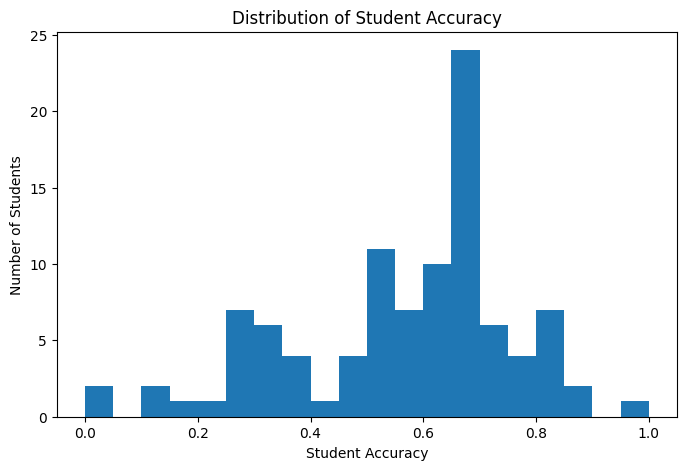

In [20]:
# SUMMARIZE QUESTION PERFORMANCE PER STUDENT
# This cell calculates student-level statistics such as total attempts, correct answers, incorrect answers, and overall accuracy.

#Student-level question statistics

student_question_stats = (
    question_attempts
    .groupby("user_id")
    .agg(
        question_attempts=("question_id", "count"),
        unique_questions=("question_id", "nunique"),
        correct_answers=("is_correct", "sum"),
        accuracy=("is_correct", "mean")
    )
    .reset_index()
)

display(student_question_stats.head(20))

plt.figure(figsize=(8, 5))
plt.hist(
    student_question_stats["accuracy"].dropna(),
    bins=20
)
plt.xlabel("Student Accuracy")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Accuracy")
plt.show()


## Skill-level behavior and mastery


In [21]:
# CONVERT QUESTION ATTEMPTS INTO SKILL-LEVEL RECORDS
# This cell expands multi-tag questions so that one question can contribute to several associated skills.
# This makes it possible to estimate mastery separately for different knowledge areas.

#Explode question attempts into skill attempts

skill_attempts = (
    question_attempts
    .explode("tag_list")
    .rename(columns={"tag_list": "skill_id"})
)

skill_attempts = skill_attempts[
    skill_attempts["skill_id"].notna()
    &
    skill_attempts["is_correct"].notna()
].copy()

skill_attempts["skill_id"] = (
    skill_attempts["skill_id"]
    .astype("string")
    .str.strip()
)

print("Skill-attempt shape:", skill_attempts.shape)

display(
    skill_attempts[
        [
            "user_id",
            "question_id",
            "skill_id",
            "is_correct"
        ]
    ].head(20)
)


Skill-attempt shape: (124694, 15)


,user_id,question_id,skill_id,is_correct
0,1,q5012,74,0.0
1,1,q4706,71,1.0
2,1,q4366,103,1.0
3,1,q4829,83,0.0
4,1,q6528,90,0.0
5,1,q4793,82,0.0
6,1,q6488,77,1.0
7,1,q356,30,1.0
7,1,q356,34,1.0
7,1,q356,42,1.0


In [22]:
# CALCULATE SKILL MASTERY
# This cell groups attempts by student and skill and estimates mastery from historical correct and incorrect responses.

# Skill mastery

if not skill_attempts.empty:

    skill_mastery = (
        skill_attempts
        .groupby(["user_id", "skill_id"])
        .agg(
            attempts=("is_correct", "count"),
            correct=("is_correct", "sum")
        )
        .reset_index()
    )

    skill_mastery["mastery"] = (
        skill_mastery["correct"]
        /
        skill_mastery["attempts"]
    )

else:

    skill_mastery = pd.DataFrame(
        columns=[
            "user_id",
            "skill_id",
            "attempts",
            "correct",
            "mastery"
        ]
    )

display(skill_mastery.head(20))


,user_id,skill_id,attempts,correct,mastery
0,1,1,1,1.0,1.000000
1,1,10,6,4.0,0.666667
2,1,100,1,1.0,1.000000
3,1,101,1,0.0,0.000000
4,1,102,2,2.0,1.000000
5,1,103,1,1.0,1.000000
6,1,104,3,2.0,0.666667
7,1,105,3,3.0,1.000000
8,1,106,6,3.0,0.500000
9,1,107,3,1.0,0.333333


In [23]:
# CALCULATE RECENT PERFORMANCE WITHOUT DATA LEAKAGE
# This cell calculates recent accuracy using only answers that occurred before the current attempt.
# This is important: the model must not use future or current outcomes when describing the state before a decision.

# Leakage-safe recent performance

question_attempts = (
    question_attempts
    .sort_values(
        ["user_id", "timestamp"]
    )
    .reset_index(drop=True)
)

question_attempts["recent_accuracy"] = (
    question_attempts
    .groupby("user_id")["is_correct"]
    .transform(
        lambda s:
            s.shift(1)
             .rolling(window=10, min_periods=1)
             .mean()
    )
    .fillna(0.5)
)

if not skill_attempts.empty:

    skill_attempts = (
        skill_attempts
        .sort_values(
            ["user_id", "skill_id", "timestamp"]
        )
        .reset_index(drop=True)
    )

    skill_attempts["recent_mastery"] = (
        skill_attempts
        .groupby(["user_id", "skill_id"])["is_correct"]
        .transform(
            lambda s:
                s.shift(1)
                 .rolling(window=10, min_periods=1)
                 .mean()
        )
        .fillna(0.5)
    )

display(
    question_attempts[
        [
            "user_id",
            "question_id",
            "is_correct",
            "recent_accuracy"
        ]
    ].head(20)
)


,user_id,question_id,is_correct,recent_accuracy
0,1,q5012,0.0,0.500000
1,1,q4706,1.0,0.000000
2,1,q4366,1.0,0.500000
3,1,q4829,0.0,0.666667
4,1,q6528,0.0,0.500000
5,1,q4793,0.0,0.400000
6,1,q6488,1.0,0.333333
7,1,q356,1.0,0.428571
8,1,q1382,1.0,0.500000
9,1,q830,1.0,0.555556


# Lecture sessions
# 
### The lecture metadata shows `video_length` in **milliseconds**.
# 
### Example:
# 
### `359000 ms = 359 seconds`
# 
### A lecture row with `video_length = -1` has no usable video duration, so its completion ratio remains `NaN`.


In [24]:
# DEFINE HOW LECTURE SESSIONS ARE RECONSTRUCTED
# This cell defines a function that converts lecture enter and quit events into lecture sessions with timing information.

# Extract lecture enter → quit sessions

def calculate_lecture_sessions(student_df):

    student_df = (
        student_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    active = {}
    sessions = []

    for _, row in student_df.iterrows():

        item_id = str(row["item_id"]).strip()
        action = str(row["action_type"]).strip().lower()

        if not item_id.startswith("l"):
            continue

        if action == "enter":

            active[item_id] = {
                "enter_time": row["timestamp"],
                "source": row["source"],
                "platform": row["platform"]
            }

        elif (
            action == "quit"
            and item_id in active
        ):

            start = active.pop(item_id)

            duration = (
                row["timestamp"]
                -
                start["enter_time"]
            ).total_seconds()

            sessions.append({
                "user_id": row["user_id"],
                "lecture_id": item_id,
                "start_time": start["enter_time"],
                "end_time": row["timestamp"],
                "duration_seconds": max(duration, 0),
                "source": start["source"],
                "platform": start["platform"]
            })

    return pd.DataFrame(
        sessions,
        columns=[
            "user_id",
            "lecture_id",
            "start_time",
            "end_time",
            "duration_seconds",
            "source",
            "platform"
        ]
    )


In [25]:
# BUILD LECTURE SESSION DATASET
# This cell applies the lecture-session function to every selected student and combines the reconstructed sessions.

# Build lecture sessions

lecture_sessions_list = []

for user_id, student_df in tqdm(
    data.groupby("user_id", sort=False),
    desc="Processing lecture sessions"
):

    result = calculate_lecture_sessions(student_df)

    if not result.empty:
        lecture_sessions_list.append(result)

if lecture_sessions_list:

    lecture_sessions = pd.concat(
        lecture_sessions_list,
        ignore_index=True
    )

else:

    lecture_sessions = pd.DataFrame(
        columns=[
            "user_id",
            "lecture_id",
            "start_time",
            "end_time",
            "duration_seconds",
            "source",
            "platform"
        ]
    )

print(
    "Lecture sessions:",
    lecture_sessions.shape
)

display(lecture_sessions.head(20))


Processing lecture sessions:   0%|          | 0/100 [00:00<?, ?it/s]

Lecture sessions: (1547, 7)


,user_id,lecture_id,start_time,end_time,duration_seconds,source,platform
0,1,l504,2019-08-06 13:03:57.922,2019-08-06 13:10:07.903,369.981,archive,mobile
1,1,l464,2019-09-10 12:57:17.376,2019-09-10 13:02:55.616,338.240,archive,mobile
2,1,l463,2019-09-10 13:02:55.929,2019-09-10 13:06:47.905,231.976,archive,mobile
3,1,l463,2019-09-10 13:07:03.309,2019-09-10 13:08:05.206,61.897,archive,mobile
4,1,l462,2019-09-10 13:08:05.352,2019-09-10 13:14:17.114,371.762,archive,mobile
5,1,l316,2019-09-10 13:14:39.019,2019-09-10 13:20:48.931,369.912,archive,mobile
6,1,l364,2019-09-16 13:42:13.448,2019-09-16 13:43:48.552,95.104,archive,mobile
7,1,l319,2019-09-16 13:43:48.654,2019-09-16 13:47:30.943,222.289,archive,mobile
8,1,l351,2019-09-16 13:47:31.033,2019-09-16 13:50:41.387,190.354,archive,mobile
9,1,l231,2019-09-22 12:12:26.219,2019-09-22 12:21:01.971,515.752,archive,mobile


In [26]:
# ADD LECTURE METADATA
# This cell merges lecture sessions with lecture information such as tags and video length.
# The merge is controlled to avoid duplicate columns or duplicated sessions.

# Merge lecture metadata EXACTLY ONCE

if not lecture_sessions.empty:

    lecture_metadata = lectures[
        [
            "lecture_id",
            "part",
            "tags",
            "video_length",
            "video_length_seconds",
            "deployed_at"
        ]
    ].copy()

    lecture_sessions = lecture_sessions.merge(
        lecture_metadata,
        on="lecture_id",
        how="left",
        validate="many_to_one"
    )

print(
    "Lecture session columns:"
)
print(lecture_sessions.columns.tolist())

display(lecture_sessions.head(20))


Lecture session columns:
['user_id', 'lecture_id', 'start_time', 'end_time', 'duration_seconds', 'source', 'platform', 'part', 'tags', 'video_length', 'video_length_seconds', 'deployed_at']


,user_id,lecture_id,start_time,end_time,duration_seconds,source,platform,part,tags,video_length,video_length_seconds,deployed_at
0,1,l504,2019-08-06 13:03:57.922,2019-08-06 13:10:07.903,369.981,archive,mobile,5,103,263000,263.0,1570425956244
1,1,l464,2019-09-10 12:57:17.376,2019-09-10 13:02:55.616,338.240,archive,mobile,3,52,181000,181.0,1570425490998
2,1,l463,2019-09-10 13:02:55.929,2019-09-10 13:06:47.905,231.976,archive,mobile,3,53,157000,157.0,1570425486721
3,1,l463,2019-09-10 13:07:03.309,2019-09-10 13:08:05.206,61.897,archive,mobile,3,53,157000,157.0,1570425486721
4,1,l462,2019-09-10 13:08:05.352,2019-09-10 13:14:17.114,371.762,archive,mobile,3,55,120000,120.0,1570425483199
5,1,l316,2019-09-10 13:14:39.019,2019-09-10 13:20:48.931,369.912,archive,mobile,-1,-1,-1,NaN,-1
6,1,l364,2019-09-16 13:42:13.448,2019-09-16 13:43:48.552,95.104,archive,mobile,-1,-1,-1,NaN,-1
7,1,l319,2019-09-16 13:43:48.654,2019-09-16 13:47:30.943,222.289,archive,mobile,-1,-1,-1,NaN,-1
8,1,l351,2019-09-16 13:47:31.033,2019-09-16 13:50:41.387,190.354,archive,mobile,-1,-1,-1,NaN,-1
9,1,l231,2019-09-22 12:12:26.219,2019-09-22 12:21:01.971,515.752,archive,mobile,-1,-1,-1,NaN,-1


In [27]:
# ESTIMATE LECTURE COMPLETION
# This cell calculates how much of a lecture was watched when valid timing and video-length information is available.

# Calculate lecture completion correctly

if not lecture_sessions.empty:

    lecture_sessions["completion_ratio"] = np.nan

    valid_length = (
        lecture_sessions["video_length_seconds"].notna()
        &
        (lecture_sessions["video_length_seconds"] > 0)
    )

    lecture_sessions.loc[
        valid_length,
        "completion_ratio"
    ] = (
        lecture_sessions.loc[
            valid_length,
            "duration_seconds"
        ]
        /
        lecture_sessions.loc[
            valid_length,
            "video_length_seconds"
        ]
    )

    lecture_sessions["completion_ratio"] = (
        lecture_sessions["completion_ratio"]
        .replace([np.inf, -np.inf], np.nan)
        .clip(0, 1)
    )

    lecture_sessions["valid_video_length"] = (
        lecture_sessions["video_length_seconds"].notna()
    )

    print(
        "Valid video-length sessions:",
        lecture_sessions["valid_video_length"].sum()
    )

    print(
        "Unavailable video-length sessions:",
        (~lecture_sessions["valid_video_length"]).sum()
    )

    print(
        "Missing completion ratio:",
        lecture_sessions["completion_ratio"].isna().sum()
    )

    print(
        "Average completion among valid sessions:",
        lecture_sessions["completion_ratio"].mean()
    )

display(
    lecture_sessions[
        [
            "user_id",
            "lecture_id",
            "duration_seconds",
            "video_length",
            "video_length_seconds",
            "completion_ratio"
        ]
    ].head(20)
)

Valid video-length sessions: 1238
Unavailable video-length sessions: 309
Missing completion ratio: 309
Average completion among valid sessions: 0.79338123894799


,user_id,lecture_id,duration_seconds,video_length,video_length_seconds,completion_ratio
0,1,l504,369.981,263000,263.0,1.000000
1,1,l464,338.240,181000,181.0,1.000000
2,1,l463,231.976,157000,157.0,1.000000
3,1,l463,61.897,157000,157.0,0.394248
4,1,l462,371.762,120000,120.0,1.000000
5,1,l316,369.912,-1,NaN,NaN
6,1,l364,95.104,-1,NaN,NaN
7,1,l319,222.289,-1,NaN,NaN
8,1,l351,190.354,-1,NaN,NaN
9,1,l231,515.752,-1,NaN,NaN


In [28]:
# CREATE STUDENT-LEVEL LECTURE FEATURES
# This cell summarizes lecture behavior for each student, producing features such as lecture counts and completion statistics.

# Student-level lecture features

if not lecture_sessions.empty:

    student_lecture_features = (
        lecture_sessions
        .groupby("user_id")
        .agg(
            lectures_watched=("lecture_id", "nunique"),
            lecture_sessions=("lecture_id", "count"),
            total_lecture_time_seconds=(
                "duration_seconds", "sum"
            ),
            avg_lecture_duration_seconds=(
                "duration_seconds", "mean"
            ),
            avg_completion=(
                "completion_ratio", "mean"
            ),
            median_completion=(
                "completion_ratio", "median"
            )
        )
        .reset_index()
    )

else:

    student_lecture_features = pd.DataFrame(
        columns=[
            "user_id",
            "lectures_watched",
            "lecture_sessions",
            "total_lecture_time_seconds",
            "avg_lecture_duration_seconds",
            "avg_completion",
            "median_completion"
        ]
    )

display(student_lecture_features.head(20))


,user_id,lectures_watched,lecture_sessions,total_lecture_time_seconds,avg_lecture_duration_seconds,avg_completion,median_completion
0,1,24,29,8158.083,281.313207,0.912638,1.000000
1,4,17,18,6037.414,335.411889,0.962901,1.000000
2,5,9,9,2249.353,249.928111,0.869471,1.000000
3,7,102,112,19625.016,175.223357,0.711621,0.861101
4,9,6,10,2120.550,212.055000,NaN,NaN
5,11,76,83,20475.026,246.687060,0.924337,1.000000
6,14,2,2,350.364,175.182000,0.981256,0.981256
7,16,139,166,55090.762,331.872060,0.817481,1.000000
8,20,2,2,47.821,23.910500,NaN,NaN
9,21,1,1,3.483,3.483000,0.012620,0.012620


## Explanation/revision sessions

In [29]:
# DEFINE EXPLANATION SESSION EXTRACTION
# This cell defines how explanation-related events are grouped into meaningful sessions.

# Extract explanation sessions

def calculate_explanation_sessions(student_df):

    student_df = (
        student_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    active = {}
    sessions = []

    for _, row in student_df.iterrows():

        item_id = str(row["item_id"]).strip()
        action = str(row["action_type"]).strip().lower()

        if not item_id.startswith("e"):
            continue

        if action == "enter":

            active[item_id] = {
                "enter_time": row["timestamp"],
                "source": row["source"],
                "platform": row["platform"]
            }

        elif (
            action == "quit"
            and item_id in active
        ):

            start = active.pop(item_id)

            duration = (
                row["timestamp"]
                -
                start["enter_time"]
            ).total_seconds()

            sessions.append({
                "user_id": row["user_id"],
                "explanation_id": item_id,
                "start_time": start["enter_time"],
                "end_time": row["timestamp"],
                "duration_seconds": max(duration, 0),
                "source": start["source"],
                "platform": start["platform"]
            })

    return pd.DataFrame(
        sessions,
        columns=[
            "user_id",
            "explanation_id",
            "start_time",
            "end_time",
            "duration_seconds",
            "source",
            "platform"
        ]
    )


In [30]:
# BUILD EXPLANATION SESSION DATASET
# This cell applies the explanation-session logic to each student and combines the results.

# Build explanation sessions

explanation_sessions_list = []

for user_id, student_df in tqdm(
    data.groupby("user_id", sort=False),
    desc="Processing explanation sessions"
):

    result = calculate_explanation_sessions(
        student_df
    )

    if not result.empty:
        explanation_sessions_list.append(result)

if explanation_sessions_list:

    explanation_sessions = pd.concat(
        explanation_sessions_list,
        ignore_index=True
    )

else:

    explanation_sessions = pd.DataFrame(
        columns=[
            "user_id",
            "explanation_id",
            "start_time",
            "end_time",
            "duration_seconds",
            "source",
            "platform"
        ]
    )

print(
    "Explanation sessions:",
    explanation_sessions.shape
)

display(explanation_sessions.head(20))



Processing explanation sessions:   0%|          | 0/100 [00:00<?, ?it/s]

Explanation sessions: (40037, 7)


,user_id,explanation_id,start_time,end_time,duration_seconds,source,platform
0,1,e356,2019-08-06 13:11:42.706,2019-08-06 13:12:27.894,45.188,sprint,mobile
1,1,e1382,2019-08-06 13:12:52.828,2019-08-06 13:13:33.739,40.911,sprint,mobile
2,1,e830,2019-08-06 13:14:01.571,2019-08-06 13:14:33.430,31.859,sprint,mobile
3,1,e8312,2019-08-06 13:14:58.887,2019-08-06 13:15:25.457,26.570,sprint,mobile
4,1,e1092,2019-08-06 13:15:48.135,2019-08-06 13:16:12.586,24.451,sprint,mobile
5,1,e524,2019-08-06 13:16:37.421,2019-08-06 13:17:04.592,27.171,sprint,mobile
6,1,e485,2019-08-06 13:17:28.760,2019-08-06 13:17:51.895,23.135,sprint,mobile
7,1,e8314,2019-08-06 13:18:17.974,2019-08-06 13:18:43.292,25.318,sprint,mobile
8,1,e1329,2019-08-06 13:19:06.076,2019-08-06 13:19:28.247,22.171,sprint,mobile
9,1,e1204,2019-08-06 13:19:49.826,2019-08-06 13:20:11.532,21.706,sprint,mobile


In [31]:
# CREATE STUDENT-LEVEL EXPLANATION FEATURES
# This cell summarizes how often and how long students interacted with explanation material.

# Student-level explanation features

if not explanation_sessions.empty:

    student_explanation_features = (
        explanation_sessions
        .groupby("user_id")
        .agg(
            explanation_sessions=(
                "explanation_id", "count"
            ),
            explanations_viewed=(
                "explanation_id", "nunique"
            ),
            total_explanation_time_seconds=(
                "duration_seconds", "sum"
            ),
            avg_explanation_duration_seconds=(
                "duration_seconds", "mean"
            )
        )
        .reset_index()
    )

else:

    student_explanation_features = pd.DataFrame(
        columns=[
            "user_id",
            "explanation_sessions",
            "explanations_viewed",
            "total_explanation_time_seconds",
            "avg_explanation_duration_seconds"
        ]
    )

display(student_explanation_features.head(20))

,user_id,explanation_sessions,explanations_viewed,total_explanation_time_seconds,avg_explanation_duration_seconds
0,1,550,482,35286.149,64.156635
1,3,1,1,25.567,25.567000
2,4,626,458,25602.487,40.898542
3,5,130,115,7814.117,60.108592
4,7,1164,874,30350.591,26.074391
5,8,4,4,344.155,86.038750
6,9,34,33,2471.326,72.686059
7,10,1,1,18.233,18.233000
8,11,2635,2135,56911.954,21.598465
9,12,34,32,5936.076,174.590471


## Combine student-level behavioral features

In [32]:
# CREATE STUDENT-LEVEL SKILL FEATURES
# This cell summarizes the detailed skill-mastery table into features that describe each student overall.

# Student-level skill features

if not skill_mastery.empty:

    student_skill_features = (
        skill_mastery
        .groupby("user_id")
        .agg(
            skills_attempted=("skill_id", "nunique"),
            avg_skill_mastery=("mastery", "mean"),
            min_skill_mastery=("mastery", "min"),
            max_skill_mastery=("mastery", "max")
        )
        .reset_index()

    )

else:

    student_skill_features = pd.DataFrame(
        columns=[
            "user_id",
            "skills_attempted",
            "avg_skill_mastery",
            "min_skill_mastery",
            "max_skill_mastery"
        ]
    )

display(student_skill_features.head(20))

,user_id,skills_attempted,avg_skill_mastery,min_skill_mastery,max_skill_mastery
0,1,157,0.712883,0.0,1.0
1,3,15,0.566667,0.0,1.0
2,4,159,0.676773,0.0,1.0
3,5,113,0.639407,0.0,1.0
4,6,11,0.090909,0.0,1.0
5,7,140,0.644415,0.0,1.0
6,8,18,0.472222,0.0,1.0
7,9,34,0.461310,0.0,1.0
8,10,1,1.000000,1.0,1.0
9,11,147,0.699714,0.0,1.0


In [33]:
# COMBINE ALL BEHAVIORAL FEATURES
# This cell joins question, lecture, explanation, and skill features into one student-level feature table.
# The result is a compact summary of each student’s observed learning behavior.

# Combine all student-level features

student_features = student_question_stats.merge(
    student_lecture_features,
    on="user_id",
    how="outer"
)

student_features = student_features.merge(
    student_explanation_features,
    on="user_id",
    how="outer"
)

student_features = student_features.merge(
    student_skill_features,
    on="user_id",
    how="outer"
)

student_features = (
    student_features
    .sort_values("user_id")
    .reset_index(drop=True)
)

# Useful derived features
if "total_lecture_time_seconds" in student_features:
    student_features["lecture_time_hours"] = (
        student_features["total_lecture_time_seconds"] / 3600
    )

student_features["questions_per_lecture"] = (
    student_features["question_attempts"]
    /
    student_features["lectures_watched"].replace(0, np.nan)
)

student_features["correct_rate_per_attempt"] = (
    student_features["correct_answers"]
    /
    student_features["question_attempts"].replace(0, np.nan)
)

print(
    "Final student feature shape:",
    student_features.shape
)

display(student_features.head(20))


Final student feature shape: (100, 22)


,user_id,question_attempts,unique_questions,correct_answers,accuracy,lectures_watched,lecture_sessions,total_lecture_time_seconds,avg_lecture_duration_seconds,avg_completion,...,explanations_viewed,total_explanation_time_seconds,avg_explanation_duration_seconds,skills_attempted,avg_skill_mastery,min_skill_mastery,max_skill_mastery,lecture_time_hours,questions_per_lecture,correct_rate_per_attempt
0,1,504,480,349.0,0.692460,24.0,29.0,8158.083,281.313207,0.912638,...,482.0,35286.149,64.156635,157,0.712883,0.0,1.0,2.266134,21.000000,0.692460
1,3,8,8,3.0,0.375000,NaN,NaN,NaN,NaN,NaN,...,1.0,25.567,25.567000,15,0.566667,0.0,1.0,NaN,NaN,0.375000
2,4,612,476,450.0,0.735294,17.0,18.0,6037.414,335.411889,0.962901,...,458.0,25602.487,40.898542,159,0.676773,0.0,1.0,1.677059,36.000000,0.735294
3,5,205,197,134.0,0.653659,9.0,9.0,2249.353,249.928111,0.869471,...,115.0,7814.117,60.108592,113,0.639407,0.0,1.0,0.624820,22.777778,0.653659
4,6,7,7,1.0,0.142857,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,11,0.090909,0.0,1.0,NaN,NaN,0.142857
5,7,1060,863,685.0,0.646226,102.0,112.0,19625.016,175.223357,0.711621,...,874.0,30350.591,26.074391,140,0.644415,0.0,1.0,5.451393,10.392157,0.646226
6,8,12,12,5.0,0.416667,NaN,NaN,NaN,NaN,NaN,...,4.0,344.155,86.038750,18,0.472222,0.0,1.0,NaN,NaN,0.416667
7,9,34,33,12.0,0.352941,6.0,10.0,2120.550,212.055000,NaN,...,33.0,2471.326,72.686059,34,0.461310,0.0,1.0,0.589042,5.666667,0.352941
8,10,1,1,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,...,1.0,18.233,18.233000,1,1.000000,1.0,1.0,NaN,NaN,1.000000
9,11,2664,2298,1809.0,0.679054,76.0,83.0,20475.026,246.687060,0.924337,...,2135.0,56911.954,21.598465,147,0.699714,0.0,1.0,5.687507,35.052632,0.679054


## RL state and transition construction

In [34]:
# DEFINE THE RL ACTION SPACE AND DISCRETIZATION RULES
# This cell defines the learning activities used as reinforcement-learning actions and helper rules for converting continuous behavior into discrete categories.
# Discretization is needed because the initial tabular RL setup uses a manageable set of states.

# Define discretization functions and RL actions

ACTIONS = [
    "LESSON",
    "QUIZ",
    "PRACTICE",
    "REVISION"
]

ACTION_TO_ID = {
    "LESSON": 0,
    "QUIZ": 1,
    "PRACTICE": 2,
    "REVISION": 3
}

def mastery_level(x):
    if pd.isna(x):
        return 1
    if x < 0.40:
        return 0
    if x < 0.70:
        return 1
    return 2

def accuracy_level(x):
    if pd.isna(x):
        return 1
    if x < 0.40:
        return 0
    if x < 0.70:
        return 1
    return 2

def lesson_level(x):
    if x <= 0:
        return 0
    if x <= 3:
        return 1
    return 2

def map_question_action(source):

    if pd.isna(source):
        return None

    source = str(source).strip().lower()

    if source == "sprint":
        return "PRACTICE"

    if source == "diagnosis":
        return "QUIZ"

    if source in {
        "tutor",
        "todays_recommendation::sprint",
        "todays_recommendation::review_quiz"
    }:
        return "QUIZ"

    if source in {
        "in_review",
        "review"
    }:
        return "REVISION"

    if source == "adaptive_offer":
        return "PRACTICE"

    return None

print("RL actions:", ACTIONS)

RL actions: ['LESSON', 'QUIZ', 'PRACTICE', 'REVISION']


In [35]:
# BUILD BUNDLE-LEVEL LEARNING OUTCOMES
# This cell groups question attempts by student and bundle to calculate the outcome of each learning bundle.
# This becomes the basis for rewards and RL decision points.

# Build bundle-level outcomes

bundle_outcomes = (
    question_attempts
    .groupby(
        ["user_id", "bundle_id"],
        sort=False
    )
    .agg(
        bundle_start_timestamp=(
            "bundle_start_timestamp",
            "min"
        ),
        submit_timestamp=(
            "submit_timestamp",
            "max"
        ),
        accuracy=(
            "is_correct",
            "mean"
        ),
        valid_answers=(
            "is_correct",
            "count"
        ),
        source=(
            "source",
            "first"
        )
    )
    .reset_index()
)

bundle_outcomes = (
    bundle_outcomes
    .sort_values(
        ["user_id", "bundle_start_timestamp"]
    )
    .reset_index(drop=True)
)

bundle_outcomes["action"] = (
    bundle_outcomes["source"]
    .apply(map_question_action)
)

print(
    "Bundle outcomes:",
    bundle_outcomes.shape
)

print("\nMapped actions:")
display(
    bundle_outcomes["action"]
    .value_counts(dropna=False)
)

print("\nUnmapped sources:")
unmapped_sources = (
    bundle_outcomes.loc[
        bundle_outcomes["action"].isna(),
        "source"
    ]
    .value_counts()
)

display(unmapped_sources.head(30))


Bundle outcomes: (28100, 8)

Mapped actions:


action
PRACTICE    23443
None         2359
QUIZ         2120
REVISION      178
Name: count, dtype: int64


Unmapped sources:


source
my_note        2231
review_quiz     128
Name: count, dtype: int64

In [36]:
# CONSTRUCT LEAKAGE-SAFE RL STATES
# This cell builds the student state before each bundle using prior mastery, recent accuracy, lecture exposure, and weak-skill information.
# Only information available before the bundle is used, which prevents the RL state from seeing the future.

# Build leakage-safe bundle states
# (also tracks each student's lecture exposure up to this point,
#  so lesson_level can be computed leakage-safely instead of using
#  the student's total lifetime lecture count for every bundle)

def build_bundle_states(question_attempts, lecture_sessions):

    # Pre-sort each user's lecture start times so we can walk through
    # them in lockstep with that user's bundles, in chronological order.
    lecture_times_by_user = {}
    if not lecture_sessions.empty:
        for user_id, user_lectures in lecture_sessions.groupby(
            "user_id",
            sort=False
        ):
            lecture_times_by_user[user_id] = sorted(
                user_lectures["start_time"].tolist()
            )

    states = []

    for user_id, user_df in question_attempts.groupby(
        "user_id",
        sort=False
    ):

        user_df = user_df.sort_values(
            "bundle_start_timestamp"
        )

        # Group questions belonging to each bundle.
        bundles = list(
            user_df.groupby(
                "bundle_id",
                sort=False
            )
        )

        recent_answers = deque(maxlen=10)

        skill_history = defaultdict(
            lambda: deque(maxlen=10)
        )

        # Pointer into this user's chronological lecture start times.
        user_lecture_times = lecture_times_by_user.get(user_id, [])
        lecture_pointer = 0
        lectures_seen = 0

        for bundle_id, bundle_df in bundles:

            bundle_df = bundle_df.sort_values(
                "timestamp"
            )

            bundle_start = (
                bundle_df[
                    "bundle_start_timestamp"
                ].iloc[0]
            )

            # Advance the pointer over every lecture the student entered
            # strictly BEFORE this bundle started. Using "<" (not "<=")
            # keeps lectures started at/after this bundle out of its state.
            while (
                lecture_pointer < len(user_lecture_times)
                and user_lecture_times[lecture_pointer] < bundle_start
            ):
                lecture_pointer += 1
                lectures_seen += 1

            if recent_answers:
                recent_accuracy = (
                    sum(recent_answers)
                    /
                    len(recent_answers)
                )
            else:
                recent_accuracy = 0.5

            skill_masteries = {}

            for skill, history in skill_history.items():
                if history:
                    skill_masteries[skill] = (
                        sum(history)
                        /
                        len(history)
                    )

            if skill_masteries:

                weak_skill = min(
                    skill_masteries,
                    key=skill_masteries.get
                )

                overall_mastery = float(
                    np.mean(
                        list(skill_masteries.values())
                    )
                )

            else:

                weak_skill = "-1"
                overall_mastery = 0.5

            states.append({
                "user_id": user_id,
                "bundle_id": bundle_id,
                "timestamp": bundle_start,
                "raw_mastery": overall_mastery,
                "raw_recent_accuracy":
                    recent_accuracy,
                "mastery_level":
                    mastery_level(overall_mastery),
                "recent_accuracy_level":
                    accuracy_level(recent_accuracy),
                "lectures_seen": lectures_seen,
                "lesson_level":
                    lesson_level(lectures_seen),
                "weak_skill":
                    str(weak_skill)
            })

            # Update history only AFTER saving the state.
            # This prevents current-bundle answers from leaking
            # into its own state.
            for _, row in bundle_df.iterrows():

                result = row["is_correct"]

                if pd.isna(result):
                    continue

                result = int(result)

                recent_answers.append(result)

                tags = row["tag_list"]

                if not isinstance(tags, list):
                    tags = []

                for skill in tags:
                    skill = str(skill).strip()
                    if skill:
                        skill_history[skill].append(result)

    return pd.DataFrame(states)

bundle_states = build_bundle_states(
    question_attempts,
    lecture_sessions
)

print(
    "Bundle states:",
    bundle_states.shape
)

display(bundle_states.head(20))


Bundle states: (28100, 10)


,user_id,bundle_id,timestamp,raw_mastery,raw_recent_accuracy,mastery_level,recent_accuracy_level,lectures_seen,lesson_level,weak_skill
0,1,b3544,2019-08-06 12:55:51.269,0.500000,0.500000,1,1,0,0,-1
1,1,b3238,2019-08-06 12:56:35.001,0.000000,0.000000,0,0,0,0,74
2,1,b2898,2019-08-06 12:57:03.119,0.500000,0.500000,1,1,0,0,74
3,1,b3361,2019-08-06 12:58:16.012,0.666667,0.666667,1,1,0,0,74
4,1,b5060,2019-08-06 12:59:01.395,0.500000,0.500000,1,1,0,0,74
5,1,b3325,2019-08-06 13:00:03.559,0.400000,0.400000,1,1,0,0,74
6,1,b5020,2019-08-06 13:01:05.497,0.333333,0.333333,0,0,0,0,74
7,1,b356,2019-08-06 13:11:16.398,0.428571,0.428571,1,1,1,1,74
8,1,b1382,2019-08-06 13:12:27.947,0.666667,0.500000,1,1,1,1,74
9,1,b830,2019-08-06 13:13:33.786,0.733333,0.555556,2,1,1,1,74


In [37]:
# CONVERT STATE COMPONENTS INTO DISCRETE STATE IDs
# This cell turns the human-readable state components into stable discrete representations and assigns IDs for tabular RL.
# It also creates a consistent vocabulary for skills used in the state.

# Convert state components into discrete RL states

# Build a stable skill vocabulary.
if not skill_attempts.empty:
    all_skill_ids = sorted(
        skill_attempts["skill_id"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )
else:
    all_skill_ids = []

skill_to_id = {
    skill: idx
    for idx, skill in enumerate(all_skill_ids)
}

bundle_states["weak_skill_id"] = (
    bundle_states["weak_skill"]
    .map(skill_to_id)
    .fillna(-1)
    .astype(int)
)

bundle_states["state"] = list(
    zip(
        bundle_states["mastery_level"],
        bundle_states["recent_accuracy_level"],
        bundle_states["lesson_level"],
        bundle_states["weak_skill_id"]
    )
)

print(
    "Unique bundle states:",
    bundle_states["state"].nunique()
)

display(
    bundle_states[
        [
            "user_id",
            "bundle_id",
            "timestamp",
            "mastery_level",
            "recent_accuracy_level",
            "lesson_level",
            "weak_skill_id",
            "state"
        ]
    ].head(20)
)


Unique bundle states: 617


,user_id,bundle_id,timestamp,mastery_level,recent_accuracy_level,lesson_level,weak_skill_id,state
0,1,b3544,2019-08-06 12:55:51.269,1,1,0,0,"(1, 1, 0, 0)"
1,1,b3238,2019-08-06 12:56:35.001,0,0,0,160,"(0, 0, 0, 160)"
2,1,b2898,2019-08-06 12:57:03.119,1,1,0,160,"(1, 1, 0, 160)"
3,1,b3361,2019-08-06 12:58:16.012,1,1,0,160,"(1, 1, 0, 160)"
4,1,b5060,2019-08-06 12:59:01.395,1,1,0,160,"(1, 1, 0, 160)"
5,1,b3325,2019-08-06 13:00:03.559,1,1,0,160,"(1, 1, 0, 160)"
6,1,b5020,2019-08-06 13:01:05.497,0,0,0,160,"(0, 0, 0, 160)"
7,1,b356,2019-08-06 13:11:16.398,1,1,1,160,"(1, 1, 1, 160)"
8,1,b1382,2019-08-06 13:12:27.947,1,1,1,160,"(1, 1, 1, 160)"
9,1,b830,2019-08-06 13:13:33.786,2,1,1,160,"(2, 1, 1, 160)"


In [38]:
# CALCULATE REWARDS
# This cell assigns a reward based on improvement in bundle accuracy and a bonus when a mastery threshold is crossed.
# The reward tells the RL algorithms which observed outcomes are more desirable.

# Calculate reward at bundle level

# Keep only bundles with a valid observed accuracy and a mapped action.
rl_bundles = bundle_outcomes[
    bundle_outcomes["accuracy"].notna()
    &
    bundle_outcomes["action"].notna()
].copy()

rl_bundles = (
    rl_bundles
    .sort_values(
        ["user_id", "bundle_start_timestamp"]
    )
    .reset_index(drop=True)
)

rl_bundles["previous_accuracy"] = (
    rl_bundles
    .groupby("user_id")["accuracy"]
    .shift(1)
    .fillna(0.5)
)

rl_bundles["delta_accuracy"] = (
    rl_bundles["accuracy"]
    -
    rl_bundles["previous_accuracy"]
)

# Reward design from the original notebook:
# positive reward for improvement and a bonus when
# performance crosses the 0.80 mastery threshold.
rl_bundles["reward"] = (
    2 * rl_bundles["delta_accuracy"]
)

rl_bundles["mastery_bonus"] = (
    (
        rl_bundles["accuracy"] >= 0.80
    )
    &
    (
        rl_bundles["previous_accuracy"] < 0.80
    )
).astype(int) * 5

rl_bundles["reward"] += (
    rl_bundles["mastery_bonus"]
)

print(
    "RL bundle rows:",
    rl_bundles.shape
)

display(
    rl_bundles[
        [
            "user_id",
            "bundle_id",
            "accuracy",
            "previous_accuracy",
            "delta_accuracy",
            "mastery_bonus",
            "reward",
            "action"
        ]
    ].head(20)
)


RL bundle rows: (25741, 12)


,user_id,bundle_id,accuracy,previous_accuracy,delta_accuracy,mastery_bonus,reward,action
0,1,b3544,0.0,0.5,-0.5,0,-1.0,QUIZ
1,1,b3238,1.0,0.0,1.0,5,7.0,QUIZ
2,1,b2898,1.0,1.0,0.0,0,0.0,QUIZ
3,1,b3361,0.0,1.0,-1.0,0,-2.0,QUIZ
4,1,b5060,0.0,0.0,0.0,0,0.0,QUIZ
5,1,b3325,0.0,0.0,0.0,0,0.0,QUIZ
6,1,b5020,1.0,0.0,1.0,5,7.0,QUIZ
7,1,b356,1.0,1.0,0.0,0,0.0,PRACTICE
8,1,b1382,1.0,1.0,0.0,0,0.0,PRACTICE
9,1,b830,1.0,1.0,0.0,0,0.0,PRACTICE


In [39]:
# CREATE COMPLETE RL TRANSITIONS
# This cell links each current state to the next state for the same student in chronological order.
# The final output follows the RL transition structure: current state, action, reward, next state, and terminal flag.

# Join current and next states correctly

state_lookup = bundle_states[
    [
        "user_id",
        "bundle_id",
        "state"
    ]
].copy()

rl_data = rl_bundles.merge(
    state_lookup,
    on=["user_id", "bundle_id"],
    how="left",
    validate="one_to_one"
)

# Each row is already one bundle, so the next state is simply the
# state of this student's next bundle, in chronological order.
rl_data = (
    rl_data
    .sort_values(
        ["user_id", "bundle_start_timestamp"]
    )
    .reset_index(drop=True)
)

rl_data["next_state"] = (
    rl_data
    .groupby("user_id")["state"]
    .shift(-1)
)

rl_data["done"] = (
    rl_data["next_state"].isna()
)

rl_data["action_id"] = (
    rl_data["action"].map(ACTION_TO_ID)
)

print(
    "RL transition shape:",
    rl_data.shape
)

display(
    rl_data[
        [
            "user_id",
            "bundle_id",
            "state",
            "action",
            "action_id",
            "reward",
            "next_state",
            "done"
        ]
    ].head(20)
)


RL transition shape: (25741, 16)


,user_id,bundle_id,state,action,action_id,reward,next_state,done
0,1,b3544,"(1, 1, 0, 0)",QUIZ,1,-1.0,"(0, 0, 0, 160)",False
1,1,b3238,"(0, 0, 0, 160)",QUIZ,1,7.0,"(1, 1, 0, 160)",False
2,1,b2898,"(1, 1, 0, 160)",QUIZ,1,0.0,"(1, 1, 0, 160)",False
3,1,b3361,"(1, 1, 0, 160)",QUIZ,1,-2.0,"(1, 1, 0, 160)",False
4,1,b5060,"(1, 1, 0, 160)",QUIZ,1,0.0,"(1, 1, 0, 160)",False
5,1,b3325,"(1, 1, 0, 160)",QUIZ,1,0.0,"(0, 0, 0, 160)",False
6,1,b5020,"(0, 0, 0, 160)",QUIZ,1,7.0,"(1, 1, 1, 160)",False
7,1,b356,"(1, 1, 1, 160)",PRACTICE,2,0.0,"(1, 1, 1, 160)",False
8,1,b1382,"(1, 1, 1, 160)",PRACTICE,2,0.0,"(2, 1, 1, 160)",False
9,1,b830,"(2, 1, 1, 160)",PRACTICE,2,0.0,"(2, 1, 1, 160)",False


In [40]:
# VALIDATE THE RL DATASET
# This cell checks that all required RL columns exist and that the constructed transitions satisfy basic structural expectations.

# RL dataset validation

required_rl_cols = [
    "user_id",
    "bundle_id",
    "state",
    "action",
    "action_id",
    "reward",
    "next_state",
    "done"
]

missing_rl = [
    c for c in required_rl_cols
    if c not in rl_data.columns
]

if missing_rl:
    raise ValueError(
        f"Missing RL columns: {missing_rl}"
    )

print("Missing values:")
display(
    rl_data[required_rl_cols]
    .isna()
    .sum()
)

print("\nActions:")
display(
    rl_data["action"].value_counts(
        dropna=False
    )
)

print("\nAction percentages:")
display(
    (
        rl_data["action"]
        .value_counts(normalize=True)
        * 100
    )
)

print("\nDone values:")
display(
    rl_data["done"].value_counts(dropna=False)
)



Missing values:


user_id         0
bundle_id       0
state           0
action          0
action_id       0
reward          0
next_state    100
done            0
dtype: int64


Actions:


action
PRACTICE    23443
QUIZ         2120
REVISION      178
Name: count, dtype: int64


Action percentages:


action
PRACTICE    91.072608
QUIZ         8.235888
REVISION     0.691504
Name: proportion, dtype: float64


Done values:


done
False    25641
True       100
Name: count, dtype: int64

In [41]:
# CHECK ACTION COVERAGE
# This cell compares the conceptual action space with the actions actually observed in the processed data.
# This reveals whether all planned actions, such as LESSON, are represented in the current dataset.

# Important action-coverage diagnostic

observed_actions = set(
    rl_data["action"].dropna().unique()
)

missing_actions = [
    action
    for action in ACTIONS
    if action not in observed_actions
]

print("Observed RL actions:", sorted(observed_actions))

if missing_actions:
    print(
        "\nWARNING: These proposed actions are not present "
        "in the question-bundle RL data:",
        missing_actions
    )

    print(
        "\nThis is expected if the current question sources only "
        "map to QUIZ/PRACTICE."
    )

    print(
        "Do NOT artificially label lecture/explanation rows as "
        "QUIZ/PRACTICE. If you want all four actions in the RL "
        "environment, the next stage should construct a unified "
        "activity-level transition table with an explicit reward "
        "rule for LESSON and REVISION."
    )
else:
    print(
        "\nAll four proposed actions are represented."
    )

Observed RL actions: ['PRACTICE', 'QUIZ', 'REVISION']


This is expected if the current question sources only map to QUIZ/PRACTICE.
Do NOT artificially label lecture/explanation rows as QUIZ/PRACTICE. If you want all four actions in the RL environment, the next stage should construct a unified activity-level transition table with an explicit reward rule for LESSON and REVISION.


Reward summary:


count    25741.000000
mean         1.023005
std          2.900014
min         -2.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: reward, dtype: float64

,mean_reward,median_reward,std_reward,samples
action,,,,
PRACTICE,1.032628,0.0,2.904734,23443
QUIZ,0.941682,0.0,2.889305,2120
REVISION,0.724204,0.0,2.331800,178


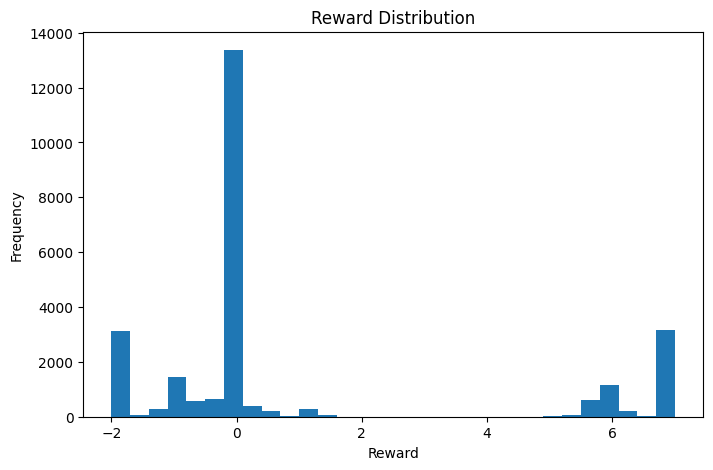

In [42]:
# INSPECT REWARD BEHAVIOR
# This cell summarizes the reward distribution overall and separately for each observed action.
# The purpose is to check whether the reward function is producing reasonable values before training RL algorithms.

# Reward diagnostics

print("Reward summary:")
display(
    rl_data["reward"].describe()
)

reward_by_action = (
    rl_data
    .groupby("action")
    .agg(
        mean_reward=("reward", "mean"),
        median_reward=("reward", "median"),
        std_reward=("reward", "std"),
        samples=("reward", "count")
    )
    .sort_values(
        "mean_reward",
        ascending=False
    )
)

display(reward_by_action)

plt.figure(figsize=(8, 5))
plt.hist(
    rl_data["reward"],
    bins=30
)
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.title("Reward Distribution")
plt.show()



Episode length summary:


count     100.000000
mean      257.410000
std       534.100662
min         1.000000
25%        10.000000
50%        33.500000
75%       153.250000
max      2586.000000
dtype: float64

Students after episode-length filtering: 98
RL transitions after filtering: 25736


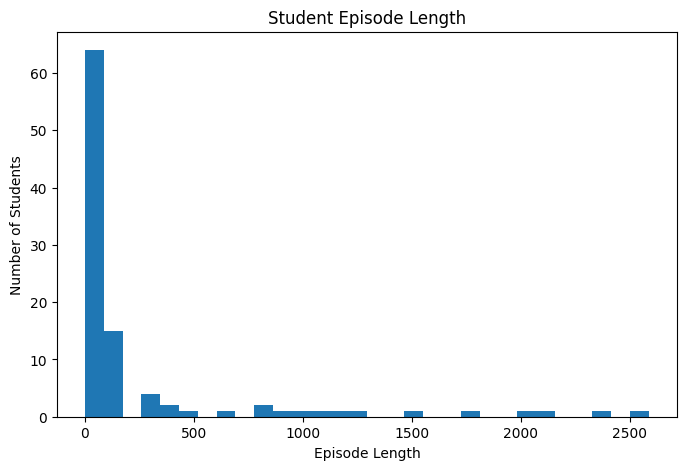

In [43]:
# FILTER VERY SHORT STUDENT EPISODES
# This cell measures the number of transitions available for each student and removes trajectories that are too short for meaningful episode-based RL analysis.

# Episode-length filtering

episode_lengths = (
    rl_data
    .groupby("user_id")
    .size()
)

print("Episode length summary:")
display(episode_lengths.describe())

valid_students = (
    episode_lengths[
        episode_lengths >= MIN_EPISODE_LENGTH
    ]
    .index
)

rl_data = rl_data[
    rl_data["user_id"].isin(valid_students)
].copy()

print(
    "Students after episode-length filtering:",
    rl_data["user_id"].nunique()
)

print(
    "RL transitions after filtering:",
    len(rl_data)
)

plt.figure(figsize=(8, 5))
plt.hist(
    episode_lengths,
    bins=30
)
plt.xlabel("Episode Length")
plt.ylabel("Number of Students")
plt.title("Student Episode Length")
plt.show()

In [44]:
# CREATE STUDENT-LEVEL TRAIN/VALIDATION/TEST SPLITS
# This cell splits students rather than randomly splitting individual rows.
# Keeping each student in only one split reduces information leakage between training and evaluation.

# Student-level train/validation/test split

students = (
    rl_data["user_id"]
    .drop_duplicates()
    .to_numpy()
)

if len(students) >= 3:

    train_students, temp_students = (
        train_test_split(
            students,
            test_size=0.30,
            random_state=RANDOM_STATE
        )
    )

    val_students, test_students = (
        train_test_split(
            temp_students,
            test_size=0.50,
            random_state=RANDOM_STATE
        )
    )

else:

    raise ValueError(
        "At least 3 students are required for a train/validation/test split."
    )

train_data = rl_data[
    rl_data["user_id"].isin(train_students)
].copy()

val_data = rl_data[
    rl_data["user_id"].isin(val_students)
].copy()

test_data = rl_data[
    rl_data["user_id"].isin(test_students)
].copy()

print("Train students:", len(train_students))
print("Validation students:", len(val_students))
print("Test students:", len(test_students))

print("\nTrain shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)


Train students: 68
Validation students: 15
Test students: 15

Train shape: (17686, 16)
Validation shape: (3266, 16)
Test shape: (4784, 16)


In [45]:
# RUN FINAL STRUCTURAL SAFETY CHECKS
# This cell uses assertions and consistency checks to catch duplicate columns, invalid values, or unexpected structural problems before saving the data.

# Final structural checks

assert "video_length" not in lecture_sessions.columns or (
    "video_length_x" not in lecture_sessions.columns
    and
    "video_length_y" not in lecture_sessions.columns
)

if not lecture_sessions.empty:
    video_cols = [
        c for c in lecture_sessions.columns
        if "video_length" in c
    ]
    print("Lecture duration columns:", video_cols)

assert rl_data["state"].notna().all()
assert rl_data["action"].notna().all()
assert rl_data["action_id"].notna().all()
assert rl_data["reward"].notna().all()

# All non-terminal transitions should have a next state.
assert (
    rl_data.loc[
        ~rl_data["done"],
        "next_state"
    ].notna().all()
)

print("All final structural checks passed.")

Lecture duration columns: ['video_length', 'video_length_seconds', 'valid_video_length']
All final structural checks passed.


In [46]:
# SAVE PROCESSED DATASETS
# This cell writes the main processed tables to the Kaggle working directory so they can be reused in later Q-Learning and Monte Carlo experiments.

# Save processed datasets to Kaggle working directory

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

outputs = {
    "question_attempts.csv": question_attempts,
    "skill_attempts.csv": skill_attempts,
    "skill_mastery.csv": skill_mastery,
    "lecture_sessions.csv": lecture_sessions,
    "explanation_sessions.csv": explanation_sessions,
    "student_features.csv": student_features,
    "bundle_states.csv": bundle_states,
    "rl_transitions.csv": rl_data,
    "train.csv": train_data,
    "validation.csv": val_data,
    "test.csv": test_data
}

for filename, df in outputs.items():
    df.to_csv(
        OUTPUT_DIR / filename,
        index=False
    )

print("CSV files saved to:")
print(OUTPUT_DIR)
for filename in outputs:
    print(" ", filename)

CSV files saved to:
/kaggle/working/cse753_processed
  question_attempts.csv
  skill_attempts.csv
  skill_mastery.csv
  lecture_sessions.csv
  explanation_sessions.csv
  student_features.csv
  bundle_states.csv
  rl_transitions.csv
  train.csv
  validation.csv
  test.csv


In [47]:
# OPTIONAL PARQUET EXPORT
# This cell optionally saves the processed tables in Parquet format, which can be efficient for larger datasets and later experiments.

# Optional Parquet export

for filename, df in outputs.items():

    parquet_path = (
        OUTPUT_DIR
        /
        filename.replace(".csv", ".parquet")
    )

    try:
        df.to_parquet(
            parquet_path,
            index=False
        )
    except Exception as e:
        print(
            f"Parquet export skipped for {filename}: {e}"
        )

print("Parquet export attempted.")

Parquet export attempted.


In [48]:
# PRINT FINAL PROJECT SUMMARY
# This cell prints the main counts and statistics from the completed preprocessing and RL transition pipeline.
# It provides a quick overview of what was successfully produced during this execution.

# Final project summary

print("=" * 70)
print("EDNET RL DATASET SUMMARY")
print("=" * 70)

print("Students loaded:", data["user_id"].nunique())
print("Question attempts:", len(question_attempts))
print("Lecture sessions:", len(lecture_sessions))
print("Explanation sessions:", len(explanation_sessions))
print("Skill-attempt rows:", len(skill_attempts))
print("Skill mastery rows:", len(skill_mastery))
print("Student feature rows:", len(student_features))

print("\nRL students:", rl_data["user_id"].nunique())
print("RL transitions:", len(rl_data))
print("Unique states:", rl_data["state"].nunique())
print("Unique actions:", rl_data["action"].nunique())
print("Average reward:", rl_data["reward"].mean())
print("Minimum reward:", rl_data["reward"].min())
print("Maximum reward:", rl_data["reward"].max())

print("\nRL action distribution:")
display(
    rl_data["action"]
    .value_counts()
)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("=" * 70)


EDNET RL DATASET SUMMARY
Students loaded: 100
Question attempts: 51523
Lecture sessions: 1547
Explanation sessions: 40037
Skill-attempt rows: 124694
Skill mastery rows: 6285
Student feature rows: 100

RL students: 98
RL transitions: 25736
Unique states: 600
Unique actions: 3
Average reward: 1.0228149932649466
Minimum reward: -2.0
Maximum reward: 7.0

RL action distribution:


action
PRACTICE    23443
QUIZ         2115
REVISION      178
Name: count, dtype: int64


Output directory:
/kaggle/working/cse753_processed


## RL agent configuration

In [49]:
import random 
import time

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Rebuild a contiguous action space from whatever actions are ACTUALLY
# present in the RL data (only 3 of the 4 proposed actions are observed;
# see the action-coverage diagnostic above). The original ACTION_TO_ID
# mapping used ids 0-3 for LESSON/QUIZ/PRACTICE/REVISION, which would leave
# gaps in a Q-table sized only for the 3 present actions.

RL_ACTIONS = sorted(rl_data["action"].dropna().unique().tolist())
RL_ACTION_TO_ID = {action: idx for idx, action in enumerate(RL_ACTIONS)}
RL_ID_TO_ACTION = {idx: action for action, idx in RL_ACTION_TO_ID.items()}

for df in (train_data, val_data, test_data):
    df["action_id"] = df["action"].map(RL_ACTION_TO_ID)

print("RL action space used for the agents:", RL_ACTIONS)
print("RL_ACTION_TO_ID:", RL_ACTION_TO_ID)


RL action space used for the agents: ['PRACTICE', 'QUIZ', 'REVISION']
RL_ACTION_TO_ID: {'PRACTICE': 0, 'QUIZ': 1, 'REVISION': 2}


In [50]:
# Simulated student environment fit from a transitions dataframe

class StudentEnv:
    """
    A simulated environment for the personalized-learning MDP.

    Built by resampling empirically observed (reward, next_state, done)
    outcomes for each (state, action) pair seen in a transitions dataframe.

    UPDATED: unsupported (state, action) pairs are no longer fabricated as
    a "self-loop" with an averaged reward. That fallback let an agent farm
    reward by repeatedly choosing an unsupported action from a favorable
    state without the episode ever progressing -- inflating training
    reward without producing genuine progress toward mastery (this is
    what the completion-rate proxy caught: random beat both trained
    agents even after the earlier reset-state bug was fixed). Unsupported
    actions are now excluded from `available_actions(state)`; an agent
    restricted to available_actions can never trigger that exploit. If a
    state has no supported actions at all, the episode simply ends there.
    """

    def __init__(self, transitions_df, action_to_id, max_steps=30, seed=None):
        self.action_to_id = action_to_id
        self.n_actions = len(action_to_id)
        self.max_steps = max_steps
        self.rng = random.Random(seed)

        self.model = defaultdict(lambda: defaultdict(list))
        for row in transitions_df.itertuples(index=False):
            self.model[row.state][row.action_id].append(
                (row.reward, row.next_state, bool(row.done))
            )

        self.all_states = list(transitions_df["state"].unique())

    def available_actions(self, state):
        """Action ids with at least one logged (state, action) example."""
        return list(self.model.get(state, {}).keys())

    def reset(self, start_state=None):
        self.t = 0
        self.state = (
            start_state if start_state is not None
            else self.rng.choice(self.all_states)
        )
        return self.state

    def step(self, action_id):
        self.t += 1
        options = self.model.get(self.state, {}).get(action_id)

        if not options:
            raise ValueError(
                f"Unsupported (state, action) pair: ({self.state}, {action_id}). "
                "Check available_actions(state) before choosing an action."
            )

        reward, next_state, done = self.rng.choice(options)
        if pd.isna(next_state):
            next_state, done = self.state, True

        done = bool(done) or self.t >= self.max_steps
        self.state = next_state
        return next_state, reward, done


print("StudentEnv defined (unsupported actions are now masked, not self-looped).")




StudentEnv defined (unsupported actions are now masked, not self-looped).


In [51]:
# Tabular Q-Learning and Monte Carlo Control

def make_q_table(n_actions):
    return defaultdict(lambda: np.zeros(n_actions))


def epsilon_greedy(Q, state, available_actions, eps, rng):
    """Epsilon-greedy restricted to `available_actions` (action ids actually
    supported for `state`). Returns None if nothing is available."""
    if not available_actions:
        return None
    if rng.random() < eps:
        return rng.choice(available_actions)
    q_values = {a: Q[state][a] for a in available_actions}
    best_value = max(q_values.values())
    best_actions = [a for a, v in q_values.items() if v == best_value]
    return rng.choice(best_actions)


def greedy_action(Q, state, available_actions):
    """Deterministic greedy action restricted to `available_actions`.
    Returns None if nothing is available from this state."""
    if not available_actions:
        return None
    q_values = {a: Q[state][a] for a in available_actions}
    best_value = max(q_values.values())
    best_actions = [a for a, v in q_values.items() if v == best_value]
    return random.choice(best_actions)


def q_learning(env, n_episodes=2000, alpha=0.1, gamma=0.95,
               eps_start=1.0, eps_end=0.05, eps_decay=0.995, seed=0):
    """Off-policy TD(0) control (Q-Learning), trained online against `env`.
    Only ever selects actions env.available_actions(state) actually supports."""

    rng = random.Random(seed)
    Q = make_q_table(env.n_actions)
    eps = eps_start
    episode_rewards = []

    for _ in range(n_episodes):
        s = env.reset()
        done = False
        total_r = 0.0

        while not done:
            available = env.available_actions(s)
            a = epsilon_greedy(Q, s, available, eps, rng)
            if a is None:
                break  # no supported action from this state: episode ends here

            s2, r, done = env.step(a)

            next_available = env.available_actions(s2)
            if done or not next_available:
                best_next = 0.0
            else:
                best_next = max(Q[s2][a2] for a2 in next_available)

            Q[s][a] += alpha * (r + gamma * best_next - Q[s][a])

            s = s2
            total_r += r

        episode_rewards.append(total_r)
        eps = max(eps_end, eps * eps_decay)

    return Q, episode_rewards


def mc_control(env, n_episodes=2000, gamma=0.95,
               eps_start=1.0, eps_end=0.05, eps_decay=0.995, seed=0):
    """On-policy first-visit Monte Carlo control, trained online against `env`.
    Only ever selects actions env.available_actions(state) actually supports."""

    rng = random.Random(seed)
    Q = make_q_table(env.n_actions)
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    eps = eps_start
    episode_rewards = []

    for _ in range(n_episodes):
        s = env.reset()
        done = False
        episode = []

        while not done:
            available = env.available_actions(s)
            a = epsilon_greedy(Q, s, available, eps, rng)
            if a is None:
                break

            s2, r, done = env.step(a)
            episode.append((s, a, r))
            s = s2

        episode_rewards.append(sum(r for _, _, r in episode))

        G = 0.0
        visited = set()
        for s_t, a_t, r_t in reversed(episode):
            G = r_t + gamma * G
            key = (s_t, a_t)
            if key not in visited:
                visited.add(key)
                returns_sum[key] += G
                returns_count[key] += 1
                Q[s_t][a_t] = returns_sum[key] / returns_count[key]

        eps = max(eps_end, eps * eps_decay)

    return Q, episode_rewards


print("q_learning() and mc_control() defined (action-masked).")




q_learning() and mc_control() defined (action-masked).


In [52]:
# Train both agents on the train-set simulator with matched hyperparameters

N_EPISODES = 3000
MAX_STEPS = 30
GAMMA = 0.95
ALPHA = 0.1
EPS_START, EPS_END, EPS_DECAY = 1.0, 0.05, 0.995

train_env = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
t0 = time.time()
Q_qlearn, rewards_qlearn = q_learning(
    train_env, n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
    eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=RANDOM_STATE
)
time_qlearn = time.time() - t0

train_env = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
t0 = time.time()
Q_mc, rewards_mc = mc_control(
    train_env, n_episodes=N_EPISODES, gamma=GAMMA,
    eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=RANDOM_STATE
)
time_mc = time.time() - t0

print(f"Q-Learning training time:       {time_qlearn:.2f}s")
print(f"Monte Carlo Control train time: {time_mc:.2f}s")
print(f"States visited by Q-Learning:    {len(Q_qlearn)}")
print(f"States visited by Monte Carlo:   {len(Q_mc)}")




Q-Learning training time:       0.43s
Monte Carlo Control train time: 0.31s
States visited by Q-Learning:    433
States visited by Monte Carlo:   433


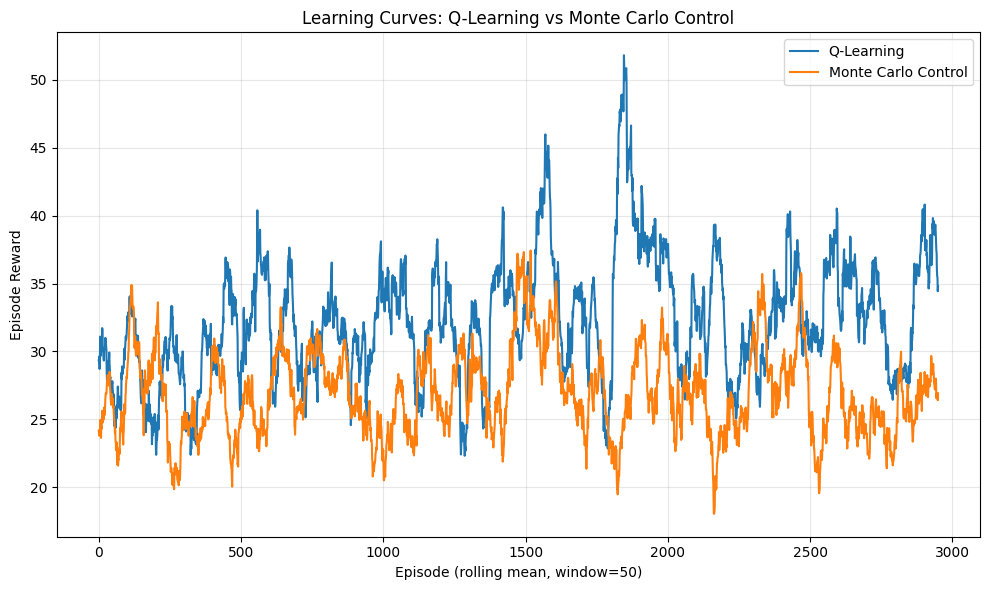

Episodes to convergence (Q-Learning):     2944
Episodes to convergence (Monte Carlo):    2927
Mean reward, last 100 episodes (Q-Learning): 37.434482905982904
Mean reward, last 100 episodes (Monte Carlo): 26.95979365079365


In [53]:
# Learning curves and convergence

def rolling_mean(x, window=50):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def episodes_to_converge(rewards, window=50, tol=0.10):
    """First episode index after which the rolling-mean reward stays within
    `tol` (relative) of its final value for the rest of training."""
    rm = rolling_mean(rewards, window)
    if len(rm) == 0:
        return None
    final_value = rm[-1]
    threshold = max(abs(final_value) * tol, 1e-6)
    for i in range(len(rm)):
        if np.all(np.abs(rm[i:] - final_value) <= threshold):
            return i
    return None


window = 50

plt.figure(figsize=(10, 6))
plt.plot(rolling_mean(rewards_qlearn, window), label="Q-Learning")
plt.plot(rolling_mean(rewards_mc, window), label="Monte Carlo Control")
plt.xlabel(f"Episode (rolling mean, window={window})")
plt.ylabel("Episode Reward")
plt.title("Learning Curves: Q-Learning vs Monte Carlo Control")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=150)
plt.show()

conv_qlearn = episodes_to_converge(rewards_qlearn, window)
conv_mc = episodes_to_converge(rewards_mc, window)

print("Episodes to convergence (Q-Learning):    ", conv_qlearn)
print("Episodes to convergence (Monte Carlo):   ", conv_mc)
print("Mean reward, last 100 episodes (Q-Learning):", np.mean(rewards_qlearn[-100:]))
print("Mean reward, last 100 episodes (Monte Carlo):", np.mean(rewards_mc[-100:]))


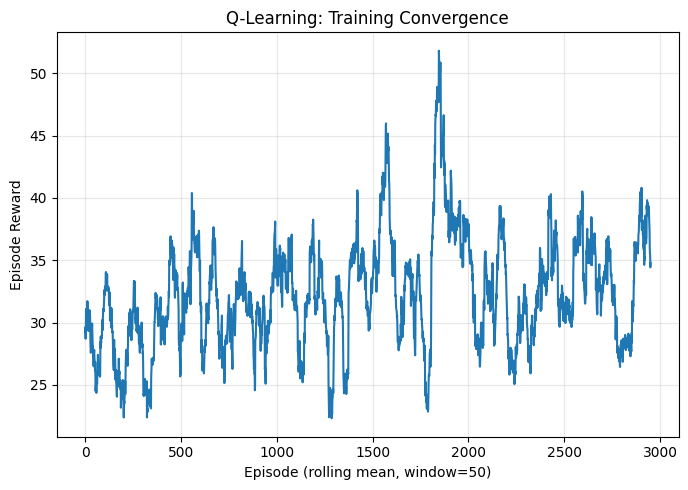

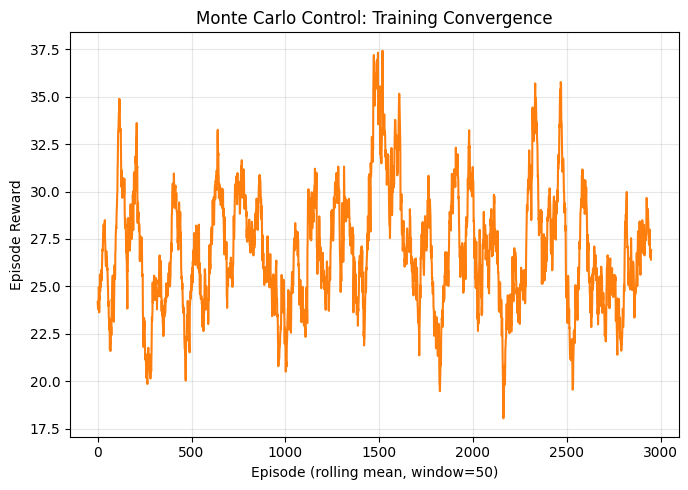

Saved: /kaggle/working/cse753_processed/qlearning_convergence.png
Saved: /kaggle/working/cse753_processed/mc_convergence.png


In [54]:
# Separate convergence plots for the LaTeX report
# (qlearning_convergence.png and mc_convergence.png)

window = 50

# --- Q-Learning ---
plt.figure(figsize=(7, 5))
plt.plot(rolling_mean(rewards_qlearn, window), color="tab:blue")
plt.xlabel(f"Episode (rolling mean, window={window})")
plt.ylabel("Episode Reward")
plt.title("Q-Learning: Training Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qlearning_convergence.png", dpi=150)
plt.show()

# --- Monte Carlo Control ---
plt.figure(figsize=(7, 5))
plt.plot(rolling_mean(rewards_mc, window), color="tab:orange")
plt.xlabel(f"Episode (rolling mean, window={window})")
plt.ylabel("Episode Reward")
plt.title("Monte Carlo Control: Training Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mc_convergence.png", dpi=150)
plt.show()

print("Saved:", OUTPUT_DIR / "qlearning_convergence.png")
print("Saved:", OUTPUT_DIR / "mc_convergence.png")

In [55]:
# Evaluate the learned greedy policies on held-out validation/test simulators

def evaluate_policy(env, Q, n_episodes=500):
    total_rewards = []
    for _ in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward = 0.0
        while not done:
            available = env.available_actions(s)
            a = greedy_action(Q, s, available)
            if a is None:
                break  # no supported action from this state: episode ends here
            s, r, done = env.step(a)
            ep_reward += r
        total_rewards.append(ep_reward)
    return np.array(total_rewards)


N_EVAL_EPISODES = 500

val_env = StudentEnv(val_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
val_rewards_qlearn = evaluate_policy(val_env, Q_qlearn, N_EVAL_EPISODES)

val_env = StudentEnv(val_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
val_rewards_mc = evaluate_policy(val_env, Q_mc, N_EVAL_EPISODES)

test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
test_rewards_qlearn = evaluate_policy(test_env, Q_qlearn, N_EVAL_EPISODES)

test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
test_rewards_mc = evaluate_policy(test_env, Q_mc, N_EVAL_EPISODES)

print("Validation mean reward (Q-Learning):    ", val_rewards_qlearn.mean())
print("Validation mean reward (Monte Carlo):   ", val_rewards_mc.mean())
print("Test mean reward (Q-Learning):          ", test_rewards_qlearn.mean())
print("Test mean reward (Monte Carlo):         ", test_rewards_mc.mean())







Validation mean reward (Q-Learning):     17.876228571428573
Validation mean reward (Monte Carlo):    17.30979365079365
Test mean reward (Q-Learning):           30.03627142857143
Test mean reward (Monte Carlo):          28.522584126984125


## Train, validation, and test convergence

The plots above only track reward on the **training** simulator as each
agent learns. To check whether the learned policy actually generalizes as
training progresses -- rather than just fitting the training simulator --
we retrain both algorithms while periodically rolling out the *current*
greedy policy on the **validation** and **test** simulators every
`EVAL_EVERY` episodes, and plot all three curves together for each
algorithm.


In [56]:
# Q-Learning / Monte Carlo Control with periodic train/val/test tracking

def q_learning_with_tracking(env, val_env, test_env, n_episodes=3000, alpha=0.1,
                              gamma=0.95, eps_start=1.0, eps_end=0.05,
                              eps_decay=0.995, seed=0, eval_every=100,
                              eval_episodes=50):
    rng = random.Random(seed)
    Q = make_q_table(env.n_actions)
    eps = eps_start
    train_curve = []
    val_curve, test_curve, eval_x = [], [], []

    for ep in range(n_episodes):
        s = env.reset()
        done = False
        total_r = 0.0

        while not done:
            available = env.available_actions(s)
            a = epsilon_greedy(Q, s, available, eps, rng)
            if a is None:
                break
            s2, r, done = env.step(a)
            next_available = env.available_actions(s2)
            best_next = 0.0 if (done or not next_available) else max(Q[s2][a2] for a2 in next_available)
            Q[s][a] += alpha * (r + gamma * best_next - Q[s][a])
            s = s2
            total_r += r

        train_curve.append(total_r)
        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % eval_every == 0:
            val_curve.append(evaluate_policy(val_env, Q, eval_episodes).mean())
            test_curve.append(evaluate_policy(test_env, Q, eval_episodes).mean())
            eval_x.append(ep + 1)

    return Q, train_curve, eval_x, val_curve, test_curve


def mc_control_with_tracking(env, val_env, test_env, n_episodes=3000, gamma=0.95,
                              eps_start=1.0, eps_end=0.05, eps_decay=0.995,
                              seed=0, eval_every=100, eval_episodes=50):
    rng = random.Random(seed)
    Q = make_q_table(env.n_actions)
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    eps = eps_start
    train_curve = []
    val_curve, test_curve, eval_x = [], [], []

    for ep in range(n_episodes):
        s = env.reset()
        done = False
        episode = []

        while not done:
            available = env.available_actions(s)
            a = epsilon_greedy(Q, s, available, eps, rng)
            if a is None:
                break
            s2, r, done = env.step(a)
            episode.append((s, a, r))
            s = s2

        train_curve.append(sum(r for _, _, r in episode))

        G = 0.0
        visited = set()
        for s_t, a_t, r_t in reversed(episode):
            G = r_t + gamma * G
            key = (s_t, a_t)
            if key not in visited:
                visited.add(key)
                returns_sum[key] += G
                returns_count[key] += 1
                Q[s_t][a_t] = returns_sum[key] / returns_count[key]

        eps = max(eps_end, eps * eps_decay)

        if (ep + 1) % eval_every == 0:
            val_curve.append(evaluate_policy(val_env, Q, eval_episodes).mean())
            test_curve.append(evaluate_policy(test_env, Q, eval_episodes).mean())
            eval_x.append(ep + 1)

    return Q, train_curve, eval_x, val_curve, test_curve


print("Tracking variants of q_learning() and mc_control() defined.")


Tracking variants of q_learning() and mc_control() defined.


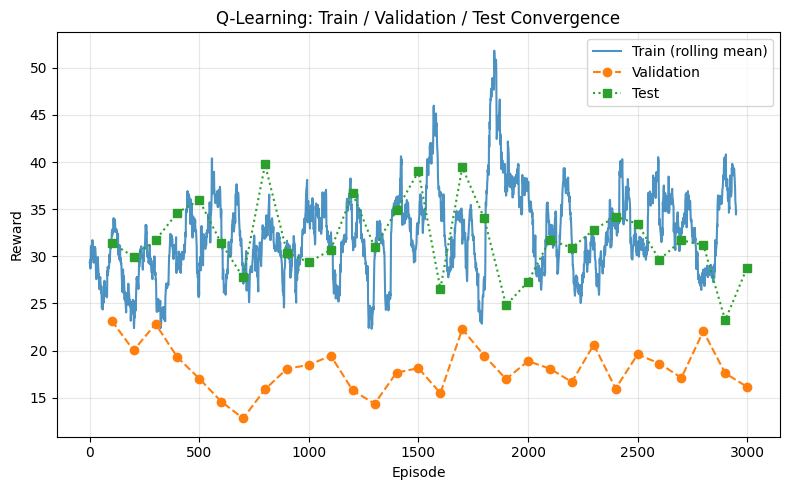

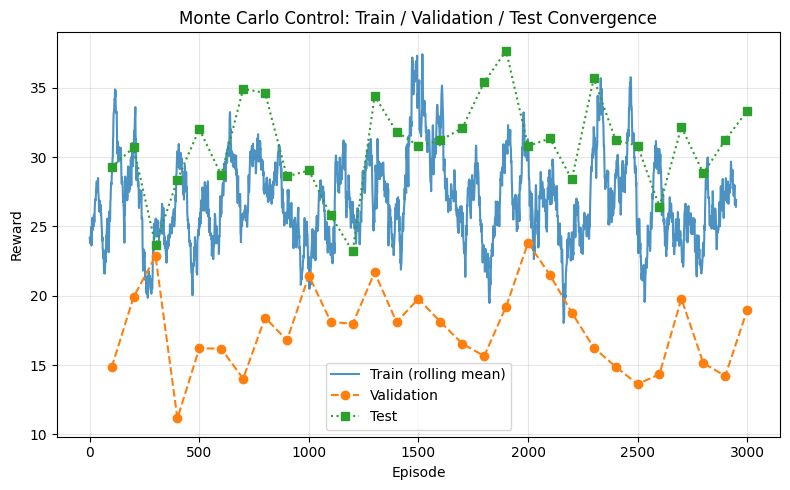

Final validation reward (Q-Learning):   16.15474603174603
Final test reward (Q-Learning):         28.804666666666666
Final validation reward (Monte Carlo):  18.957031746031745
Final test reward (Monte Carlo):        33.338523809523814


In [57]:
# Retrain both algorithms with train/val/test tracking (same
# hyperparameters as the main run, so these figures are directly
# comparable to the training-only plots above)

EVAL_EVERY = 100
EVAL_EPISODES = 50

train_env_track = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
val_env_track = StudentEnv(val_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
test_env_track = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)

Q_qlearn_tr, qlearn_train_curve, qlearn_eval_x, qlearn_val_curve, qlearn_test_curve = q_learning_with_tracking(
    train_env_track, val_env_track, test_env_track, n_episodes=N_EPISODES,
    alpha=ALPHA, gamma=GAMMA, eps_start=EPS_START, eps_end=EPS_END,
    eps_decay=EPS_DECAY, seed=RANDOM_STATE, eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
)

train_env_track = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
val_env_track = StudentEnv(val_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
test_env_track = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)

Q_mc_tr, mc_train_curve, mc_eval_x, mc_val_curve, mc_test_curve = mc_control_with_tracking(
    train_env_track, val_env_track, test_env_track, n_episodes=N_EPISODES,
    gamma=GAMMA, eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY,
    seed=RANDOM_STATE, eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES,
)

# --- Q-Learning: train vs validation vs test ---
plt.figure(figsize=(8, 5))
plt.plot(rolling_mean(qlearn_train_curve, 50), label="Train (rolling mean)", alpha=0.8)
plt.plot(qlearn_eval_x, qlearn_val_curve, label="Validation", marker="o", linestyle="--")
plt.plot(qlearn_eval_x, qlearn_test_curve, label="Test", marker="s", linestyle=":")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning: Train / Validation / Test Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qlearning_train_val_test_convergence.png", dpi=150)
plt.show()

# --- Monte Carlo Control: train vs validation vs test ---
plt.figure(figsize=(8, 5))
plt.plot(rolling_mean(mc_train_curve, 50), label="Train (rolling mean)", alpha=0.8)
plt.plot(mc_eval_x, mc_val_curve, label="Validation", marker="o", linestyle="--")
plt.plot(mc_eval_x, mc_test_curve, label="Test", marker="s", linestyle=":")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Monte Carlo Control: Train / Validation / Test Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mc_train_val_test_convergence.png", dpi=150)
plt.show()

print("Final validation reward (Q-Learning):  ", qlearn_val_curve[-1])
print("Final test reward (Q-Learning):        ", qlearn_test_curve[-1])
print("Final validation reward (Monte Carlo): ", mc_val_curve[-1])
print("Final test reward (Monte Carlo):       ", mc_test_curve[-1])


In [58]:
# Recommendation accuracy against held-out test transitions

def build_available_actions(transitions_df):
    """Map state -> set of action ids with at least one logged example in
    this dataframe. Used so recommendations never consider an action the
    training data gave no evidence for (same masking rule as StudentEnv)."""
    available = defaultdict(set)
    for row in transitions_df.itertuples(index=False):
        available[row.state].add(row.action_id)
    return available


TRAIN_AVAILABLE_ACTIONS = build_available_actions(train_data)


def recommendation_accuracy(Q, eval_df, action_to_id, available_actions_map):
    # (a) agreement with the historically logged action at that state
    logged_matches = 0

    # (b) agreement with whichever action had the highest average
    #     observed reward at that state, i.e. "did the agent find the
    #     empirically better recommendation, not just mimic the logged tutor"
    best_action_by_state = (
        eval_df.groupby(["state", "action_id"])["reward"]
        .mean()
        .reset_index()
        .sort_values("reward", ascending=False)
        .drop_duplicates("state")
        .set_index("state")["action_id"]
        .to_dict()
    )
    best_matches = 0
    n_evaluated = 0

    for row in eval_df.itertuples(index=False):
        s = row.state
        available = list(available_actions_map.get(s, []))
        greedy_a = greedy_action(Q, s, available)

        if greedy_a is None:
            continue  # training data gave no supported action for this state

        n_evaluated += 1

        if greedy_a == row.action_id:
            logged_matches += 1

        if s in best_action_by_state and greedy_a == best_action_by_state[s]:
            best_matches += 1

    if n_evaluated == 0:
        return {
            "agreement_with_logged_action": None,
            "agreement_with_empirically_best_action": None,
            "n_evaluated": 0,
        }

    return {
        "agreement_with_logged_action": logged_matches / n_evaluated,
        "agreement_with_empirically_best_action": best_matches / n_evaluated,
        "n_evaluated": n_evaluated,
    }


acc_qlearn = recommendation_accuracy(Q_qlearn, test_data, RL_ACTION_TO_ID, TRAIN_AVAILABLE_ACTIONS)
acc_mc = recommendation_accuracy(Q_mc, test_data, RL_ACTION_TO_ID, TRAIN_AVAILABLE_ACTIONS)

print("Q-Learning recommendation accuracy:    ", acc_qlearn)
print("Monte Carlo recommendation accuracy:   ", acc_mc)




Q-Learning recommendation accuracy:     {'agreement_with_logged_action': 0.8788332086761406, 'agreement_with_empirically_best_action': 0.9267015706806283, 'n_evaluated': 1337}
Monte Carlo recommendation accuracy:    {'agreement_with_logged_action': 0.8085265519820494, 'agreement_with_empirically_best_action': 0.8548990276738968, 'n_evaluated': 1337}


In [59]:
# Student completion-rate proxy: fraction of episodes reaching the top
# mastery_level (index 0 of the state tuple) under a greedy policy,
# compared against a random-action baseline.


def completion_rate(env, Q, n_episodes=500, target_mastery_level=2, seed=0):
    non_mastered_states = [
        s for s in env.all_states
        if isinstance(s, tuple) and s[0] != target_mastery_level
    ]
    if not non_mastered_states:
        print("WARNING: no non-mastered states available in this split; "
              "completion_rate is undefined.")
        return None

    rng = random.Random(seed)
    reached = 0
    for _ in range(n_episodes):
        start_state = rng.choice(non_mastered_states)
        s = env.reset(start_state=start_state)
        done = False
        while not done:
            available = env.available_actions(s)
            if Q is not None:
                a = greedy_action(Q, s, available)
            else:
                a = rng.choice(available) if available else None
            if a is None:
                break  # no supported action from this state: episode ends here
            s, r, done = env.step(a)
            if isinstance(s, tuple) and s[0] == target_mastery_level:
                reached += 1
                break
    return reached / n_episodes


test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
cr_qlearn = completion_rate(test_env, Q_qlearn, N_EVAL_EPISODES, seed=RANDOM_STATE)

test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
cr_mc = completion_rate(test_env, Q_mc, N_EVAL_EPISODES, seed=RANDOM_STATE)

test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=RANDOM_STATE)
cr_random = completion_rate(test_env, None, N_EVAL_EPISODES, seed=RANDOM_STATE)

print("Completion rate proxy (Q-Learning):     ", cr_qlearn)
print("Completion rate proxy (Monte Carlo):    ", cr_mc)
print("Completion rate proxy (random baseline):", cr_random)






Completion rate proxy (Q-Learning):      0.468
Completion rate proxy (Monte Carlo):     0.442
Completion rate proxy (random baseline): 0.424


In [60]:
# Final comparison table (headline result for the report)

comparison_table = pd.DataFrame([
    {
        "algorithm": "Q-Learning",
        "train_reward_last100": np.mean(rewards_qlearn[-100:]),
        "episodes_to_converge": conv_qlearn,
        "val_mean_reward": val_rewards_qlearn.mean(),
        "test_mean_reward": test_rewards_qlearn.mean(),
        "recommendation_accuracy_vs_logged": acc_qlearn["agreement_with_logged_action"],
        "recommendation_accuracy_vs_best": acc_qlearn["agreement_with_empirically_best_action"],
        "completion_rate_proxy": cr_qlearn,
        "training_time_seconds": time_qlearn,
    },
    {
        "algorithm": "Monte Carlo Control",
        "train_reward_last100": np.mean(rewards_mc[-100:]),
        "episodes_to_converge": conv_mc,
        "val_mean_reward": val_rewards_mc.mean(),
        "test_mean_reward": test_rewards_mc.mean(),
        "recommendation_accuracy_vs_logged": acc_mc["agreement_with_logged_action"],
        "recommendation_accuracy_vs_best": acc_mc["agreement_with_empirically_best_action"],
        "completion_rate_proxy": cr_mc,
        "training_time_seconds": time_mc,
    },
])

comparison_table.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)

print("Saved comparison table to:", OUTPUT_DIR / "algorithm_comparison.csv")
display(comparison_table)





Saved comparison table to: /kaggle/working/cse753_processed/algorithm_comparison.csv


,algorithm,train_reward_last100,episodes_to_converge,val_mean_reward,test_mean_reward,recommendation_accuracy_vs_logged,recommendation_accuracy_vs_best,completion_rate_proxy,training_time_seconds
0,Q-Learning,37.434483,2944,17.876229,30.036271,0.878833,0.926702,0.468,0.428788
1,Monte Carlo Control,26.959794,2927,17.309794,28.522584,0.808527,0.854899,0.442,0.312019


In [61]:
# add the Random policy baseline to the final comparison table

random_row = {
    "algorithm": "Random",
    "train_reward_last100": None,
    "episodes_to_converge": None,
    "val_mean_reward": None,
    "test_mean_reward": None,
    "recommendation_accuracy_vs_logged": None,
    "recommendation_accuracy_vs_best": None,
    "completion_rate_proxy": cr_random,
    "training_time_seconds": 0.0,
}

comparison_table = pd.concat(
    [comparison_table, pd.DataFrame([random_row])],
    ignore_index=True
)

comparison_table.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)

print("Updated comparison table (now includes Random baseline):")
display(comparison_table)

Updated comparison table (now includes Random baseline):


,algorithm,train_reward_last100,episodes_to_converge,val_mean_reward,test_mean_reward,recommendation_accuracy_vs_logged,recommendation_accuracy_vs_best,completion_rate_proxy,training_time_seconds
0,Q-Learning,37.434483,2944,17.876229,30.036271,0.878833,0.926702,0.468,0.428788
1,Monte Carlo Control,26.959794,2927,17.309794,28.522584,0.808527,0.854899,0.442,0.312019
2,Random,NaN,None,NaN,NaN,NaN,NaN,0.424,0.000000


In [62]:
# MULTI-SEED EVALUATION 
# Retrains Q-Learning and Monte Carlo Control from scratch under 5 different seeds
# and reports Mean +/- SD for Average Return and Mastery Success Rate

SEEDS = [0, 1, 2, 3, 4]

multi_seed_records = []

for seed in tqdm(SEEDS, desc="Multi-seed runs"):

    # --- Q-Learning ---
    train_env = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    t0 = time.time()
    Q_q_s, rewards_q_s = q_learning(
        train_env, n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
        eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=seed
    )
    t_q_s = time.time() - t0

    test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    test_r_q_s = evaluate_policy(test_env, Q_q_s, N_EVAL_EPISODES)

    test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    cr_q_s = completion_rate(test_env, Q_q_s, N_EVAL_EPISODES, seed=seed)

    multi_seed_records.append({
        "algorithm": "Q-Learning", "seed": seed,
        "test_average_return": test_r_q_s.mean(),
        "mastery_success_rate": cr_q_s,
        "training_time_seconds": t_q_s,
    })

    # --- Monte Carlo Control ---
    train_env = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    t0 = time.time()
    Q_mc_s, rewards_mc_s = mc_control(
        train_env, n_episodes=N_EPISODES, gamma=GAMMA,
        eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=seed
    )
    t_mc_s = time.time() - t0

    test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    test_r_mc_s = evaluate_policy(test_env, Q_mc_s, N_EVAL_EPISODES)

    test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    cr_mc_s = completion_rate(test_env, Q_mc_s, N_EVAL_EPISODES, seed=seed)

    multi_seed_records.append({
        "algorithm": "Monte Carlo Control", "seed": seed,
        "test_average_return": test_r_mc_s.mean(),
        "mastery_success_rate": cr_mc_s,
        "training_time_seconds": t_mc_s,
    })

multi_seed_df = pd.DataFrame(multi_seed_records)
multi_seed_df.to_csv(OUTPUT_DIR / "multi_seed_results.csv", index=False)

multi_seed_summary = (
    multi_seed_df
    .groupby("algorithm")
    .agg(
        return_mean=("test_average_return", "mean"),
        return_std=("test_average_return", "std"),
        mastery_mean=("mastery_success_rate", "mean"),
        mastery_std=("mastery_success_rate", "std"),
        time_mean=("training_time_seconds", "mean"),
    )
)

multi_seed_summary["Average Return (mean +/- sd)"] = (
    multi_seed_summary["return_mean"].round(2).astype(str)
    + " +/- " + multi_seed_summary["return_std"].round(2).astype(str)
)
multi_seed_summary["Mastery Success Rate (mean +/- sd)"] = (
    (multi_seed_summary["mastery_mean"] * 100).round(1).astype(str) + "%"
    + " +/- " + (multi_seed_summary["mastery_std"] * 100).round(1).astype(str) + "%"
)

multi_seed_summary.to_csv(OUTPUT_DIR / "multi_seed_summary.csv")

print("Multi-seed summary (5 seeds):")
display(multi_seed_summary[["Average Return (mean +/- sd)", "Mastery Success Rate (mean +/- sd)", "time_mean"]])


Multi-seed runs:   0%|          | 0/5 [00:00<?, ?it/s]

Multi-seed summary (5 seeds):


,Average Return (mean +/- sd),Mastery Success Rate (mean +/- sd),time_mean
algorithm,,,
Monte Carlo Control,30.86 +/- 0.78,42.0% +/- 2.4%,0.312749
Q-Learning,31.88 +/- 0.92,43.1% +/- 2.7%,0.440962


In [63]:
# HYPERPARAMETER ANALYSIS (multi-seed)
# Each configuration is repeated across HP_SEEDS different seeds
# (>= 3, per the professor's request) and the mean +/- SD test average
# return is reported, instead of a single run per configuration.



HP_SEEDS = [0, 1, 2]

hyperparam_configs = [
    {"alpha": 0.05, "gamma": 0.90, "episodes": 1000},
    {"alpha": 0.10, "gamma": 0.95, "episodes": 5000},
    {"alpha": 0.20, "gamma": 0.99, "episodes": 10000},
]

hp_records = []

for cfg in tqdm(hyperparam_configs, desc="Hyperparameter grid"):
    for seed in HP_SEEDS:

        # Q-Learning
        train_env = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
        Q_hp, _ = q_learning(
            train_env, n_episodes=cfg["episodes"], alpha=cfg["alpha"], gamma=cfg["gamma"],
            eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=seed
        )
        val_env = StudentEnv(val_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
        val_return = evaluate_policy(val_env, Q_hp, N_EVAL_EPISODES).mean()
        test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
        test_return = evaluate_policy(test_env, Q_hp, N_EVAL_EPISODES).mean()

        hp_records.append({
            "algorithm": "Q-Learning", "seed": seed, **cfg,
            "val_average_return": val_return, "test_average_return": test_return
        })

        # Monte Carlo Control
        train_env = StudentEnv(train_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
        Q_mc_hp, _ = mc_control(
            train_env, n_episodes=cfg["episodes"], gamma=cfg["gamma"],
            eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=seed
        )
        val_env = StudentEnv(val_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
        val_return_mc = evaluate_policy(val_env, Q_mc_hp, N_EVAL_EPISODES).mean()
        test_env = StudentEnv(test_data, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
        test_return_mc = evaluate_policy(test_env, Q_mc_hp, N_EVAL_EPISODES).mean()

        hp_records.append({
            "algorithm": "Monte Carlo Control", "seed": seed, **cfg,
            "val_average_return": val_return_mc, "test_average_return": test_return_mc
        })

hp_df = pd.DataFrame(hp_records)
hp_df.to_csv(OUTPUT_DIR / "hyperparameter_analysis_multiseed.csv", index=False)

hp_summary = (
    hp_df.groupby(["algorithm", "alpha", "gamma"])
    .agg(
        test_return_mean=("test_average_return", "mean"),
        test_return_std=("test_average_return", "std"),
    )
    .reset_index()
)
hp_summary.to_csv(OUTPUT_DIR / "hyperparameter_analysis_summary.csv", index=False)

print(f"Q-Learning hyperparameter analysis (mean +/- sd over {len(HP_SEEDS)} seeds):")
display(hp_summary[hp_summary["algorithm"] == "Q-Learning"])

print(f"\nMonte Carlo Control hyperparameter analysis (mean +/- sd over {len(HP_SEEDS)} seeds):")
display(hp_summary[hp_summary["algorithm"] == "Monte Carlo Control"])

Hyperparameter grid:   0%|          | 0/3 [00:00<?, ?it/s]

Q-Learning hyperparameter analysis (mean +/- sd over 3 seeds):


,algorithm,alpha,gamma,test_return_mean,test_return_std
3,Q-Learning,0.05,0.90,31.325588,0.389855
4,Q-Learning,0.10,0.95,30.511697,0.559309
5,Q-Learning,0.20,0.99,31.429262,1.479600



Monte Carlo Control hyperparameter analysis (mean +/- sd over 3 seeds):


,algorithm,alpha,gamma,test_return_mean,test_return_std
0,Monte Carlo Control,0.05,0.90,31.038050,1.998718
1,Monte Carlo Control,0.10,0.95,31.872880,0.482997
2,Monte Carlo Control,0.20,0.99,32.016013,1.342163


In [64]:
# ABLATION STUDY (multi-seed)
# The full state tuple built earlier is:
#   (mastery_level, recent_accuracy_level, lesson_level, weak_skill_id)
#     = (Skill Mastery, Recent Accuracy, Learning Progression, Learning History/weak-skill)
# Each ablation collapses one dimension to a single constant value so the RL agent
# can no longer condition on it, retrains Q-Learning under identical
# hyperparameters, and reports the test average return.
#
# Now repeated across ABLATION_SEEDS different seeds (>= 3, per the
# professor's request), including the "Full proposed state" baseline
# itself, so every row in the table is a mean +/- SD over the same seeds
# rather than a single run each.

ABLATION_SEEDS = [0, 1, 2]


def build_ablated_rl_data(rl_data_full, drop_index):
    """Return a copy of rl_data with one dimension of the state/next_state tuples
    collapsed to a constant, simulating removing that feature from the state."""
    ablated = rl_data_full.copy()

    def collapse(state_tuple):
        if not isinstance(state_tuple, tuple):
            return state_tuple
        state_tuple = list(state_tuple)
        state_tuple[drop_index] = 0
        return tuple(state_tuple)

    ablated["state"] = ablated["state"].apply(collapse)
    ablated["next_state"] = ablated["next_state"].apply(
        lambda s: collapse(s) if isinstance(s, tuple) else s
    )
    return ablated


def run_ablation_config(train_df, test_df, seed):
    train_env_ab = StudentEnv(train_df, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    Q_ab, _ = q_learning(
        train_env_ab, n_episodes=N_EPISODES, alpha=ALPHA, gamma=GAMMA,
        eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY, seed=seed
    )
    test_env_ab = StudentEnv(test_df, RL_ACTION_TO_ID, max_steps=MAX_STEPS, seed=seed)
    test_rewards_ab = evaluate_policy(test_env_ab, Q_ab, N_EVAL_EPISODES)
    return test_rewards_ab.mean()


ablation_dims = {
    "Without skill mastery": 0,
    "Without recent performance": 1,
    "Without learning progression": 2,
    "Without learning history (weak-skill)": 3,
}

rl_data_fixed = pd.concat([train_data, val_data, test_data], ignore_index=True)

ablation_records = []

# "Full proposed state" baseline -- run across the SAME seeds as the
# ablated configurations, so the comparison is on equal footing.
for seed in ABLATION_SEEDS:
    r = run_ablation_config(train_data, test_data, seed)
    ablation_records.append({"State Configuration": "Full proposed state", "seed": seed, "Test Average Return": r})

for label, dim in tqdm(ablation_dims.items(), desc="Ablation study"):
    ablated_all = build_ablated_rl_data(rl_data_fixed, dim)
    ablated_train = ablated_all[ablated_all["user_id"].isin(train_students)].copy()
    ablated_test = ablated_all[ablated_all["user_id"].isin(test_students)].copy()

    for seed in ABLATION_SEEDS:
        r = run_ablation_config(ablated_train, ablated_test, seed)
        ablation_records.append({"State Configuration": label, "seed": seed, "Test Average Return": r})

ablation_df = pd.DataFrame(ablation_records)
ablation_df.to_csv(OUTPUT_DIR / "ablation_study_multiseed.csv", index=False)

ablation_summary = (
    ablation_df.groupby("State Configuration")["Test Average Return"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "Test Average Return (mean)", "std": "Test Average Return (std)"})
    .reindex(["Full proposed state"] + list(ablation_dims.keys()))
    .reset_index()
)
ablation_summary.to_csv(OUTPUT_DIR / "ablation_study_summary.csv", index=False)

print(f"Ablation study of the proposed state representation (mean +/- sd over {len(ABLATION_SEEDS)} seeds):")
display(ablation_summary)


Ablation study:   0%|          | 0/4 [00:00<?, ?it/s]

Ablation study of the proposed state representation (mean +/- sd over 3 seeds):


,State Configuration,Test Average Return (mean),Test Average Return (std)
0,Full proposed state,31.571151,0.714766
1,Without skill mastery,31.871485,0.308594
2,Without recent performance,29.986316,0.301463
3,Without learning progression,33.688342,1.012018
4,Without learning history (weak-skill),37.883310,0.881336


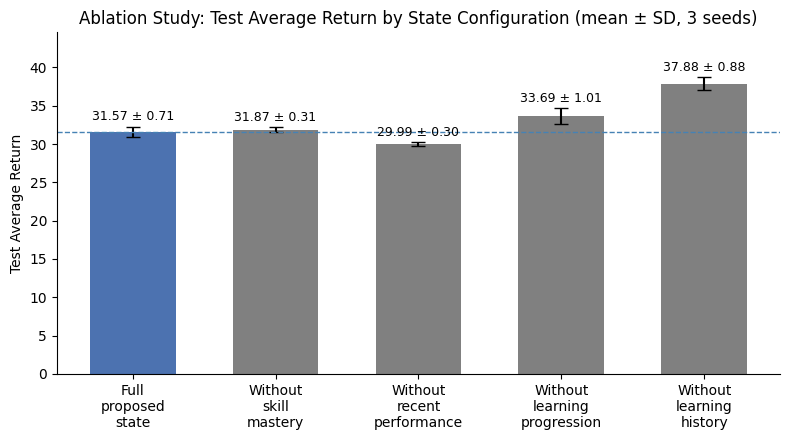

In [65]:
# Ablation study bar chart (now with error bars across seeds)
fig, ax = plt.subplots(figsize=(8, 4.5))

labels = [
    "Full\nproposed\nstate",
    "Without\nskill\nmastery",
    "Without\nrecent\nperformance",
    "Without\nlearning\nprogression",
    "Without\nlearning\nhistory",
]
means = ablation_summary["Test Average Return (mean)"].values
stds = ablation_summary["Test Average Return (std)"].values
colors = ["#4C72B0"] + ["gray"] * (len(means) - 1)  # first bar highlighted

bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors, width=0.6)

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.4,
             f"{m:.2f} \u00b1 {s:.2f}", ha="center", va="bottom", fontsize=9)

ax.axhline(means[0], color="steelblue", linestyle="--", linewidth=1)

ax.set_ylabel("Test Average Return")
ax.set_title(f"Ablation Study: Test Average Return by State Configuration (mean \u00b1 SD, {len(ABLATION_SEEDS)} seeds)")
ax.set_ylim(0, max(means + stds) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_study.png", dpi=300)
plt.show()


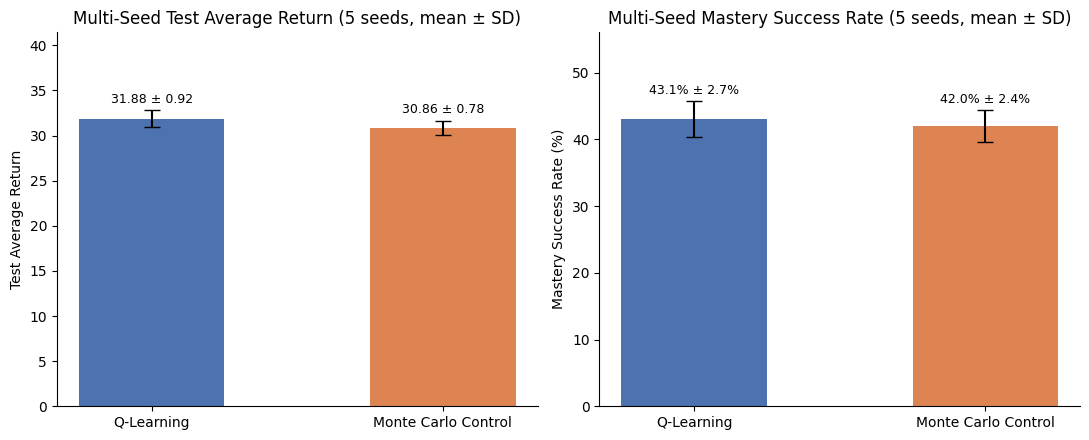

In [66]:
# Multi-seed comparison (Test Average Return + Mastery Success Rate)
summary = multi_seed_df.groupby("algorithm").agg(
    return_mean=("test_average_return", "mean"),
    return_std=("test_average_return", "std"),
    mastery_mean=("mastery_success_rate", "mean"),
    mastery_std=("mastery_success_rate", "std"),
)

algos = ["Q-Learning", "Monte Carlo Control"]
colors = ["#4C72B0", "#DD8452"]  # blue, orange

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --- Left panel: Test Average Return ---
ax = axes[0]
means = summary.loc[algos, "return_mean"].values
stds = summary.loc[algos, "return_std"].values
bars = ax.bar(algos, means, yerr=stds, capsize=6, color=colors, width=0.5)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.5,
             f"{m:.2f} ± {s:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Test Average Return")
ax.set_title("Multi-Seed Test Average Return (5 seeds, mean ± SD)")
ax.set_ylim(0, max(means) * 1.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Right panel: Mastery Success Rate ---
ax = axes[1]
means_m = summary.loc[algos, "mastery_mean"].values * 100
stds_m = summary.loc[algos, "mastery_std"].values * 100
bars = ax.bar(algos, means_m, yerr=stds_m, capsize=6, color=colors, width=0.5)
for bar, m, s in zip(bars, means_m, stds_m):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.5,
             f"{m:.1f}% ± {s:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Mastery Success Rate (%)")
ax.set_title("Multi-Seed Mastery Success Rate (5 seeds, mean ± SD)")
ax.set_ylim(0, max(means_m) * 1.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multiseed_comparison.png", dpi=300)
plt.show()